## Notebook 5: Vegetation

In [1]:
# Repo-root discovery + import of cityheat
import sys
from pathlib import Path

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError("Could not find repo root with 'cityheat' and 'configs' folders.")

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
C = bootstrap("Rome")  # switch to "Barcelona" later

PROJECT, CITY, CFG, cfg = C["PROJECT"], C["CITY"], C["CFG"], C["cfg"]
OUT, INT, BASE = C["OUT"], C["INT"], C["BASE"]
p_LCZ, p_UrbClim, p_GVI, p_CoolEff = C["p_LCZ"], C["p_UrbClim"], C["p_GVI"], C["p_CoolEff"]

print("Repo root:", ROOT)
print("✔ Loaded config:", CFG)
print("→ Outputs:", OUT)
print("→ Data base:", BASE)

Repo root: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat
✔ Loaded config: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/configs/rome.yml
→ Outputs: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome
→ Data base: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome


**Loading what we need from previous notebooks**

In [2]:
import json, numpy as np, pandas as pd, geopandas as gpd, matplotlib.pyplot as plt
import rasterio as rio
from rasterio.transform import array_bounds

plt.rcParams.update({"figure.dpi": 130})

# from Notebook 2
tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
age_npz   = INT / "age_on_ref.npz"
pop_npz   = INT / "pop_on_ref.npz"
fua_gp    = OUT / "rome_fua.gpkg"

with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

if not fua_gp.exists():
    raise FileNotFoundError("rome_fua.gpkg missing — re-run Notebook 2.")
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

# plotting footprint (NaN outside city)
ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

print("WBGT grid:", (HGT, WDT), "| CRS:", ref_meta["crs"])
print("CITY_MASK true pixels:", int(CITY_MASK.sum()))

WBGT grid: (266, 353) | CRS: EPSG:4326
CITY_MASK true pixels: 76050


In [3]:
import numpy as np
import rasterio as rio
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio import features
from scipy import ndimage as ndi

# FUA mask on the reference grid 
fua_ref = fua.to_crs(ref_meta["crs"])
fua_mask_ref = features.rasterize(
    [(geom, 1) for geom in fua_ref.geometry],
    out_shape=(ref_meta["height"], ref_meta["width"]),
    transform=ref_meta["transform"], fill=0, dtype="uint8"
).astype(bool)

# LCZ -> ref grid 
def lcz_to_ref_stream(path, ref_meta):
    with rio.open(path) as src:
        src_nod = src.nodata if src.nodata is not None else 0  # LCZ uses 0 as nodata
        vrt_opts = dict(
            crs=ref_meta["crs"],
            transform=ref_meta["transform"],
            width=ref_meta["width"],
            height=ref_meta["height"],
            resampling=Resampling.nearest,
            src_nodata=src_nod,
            nodata=np.nan,              # output NaN where LCZ is nodata
        )
        with WarpedVRT(src, **vrt_opts) as vrt:
            dst = vrt.read(1, out_dtype="float32")  # only the Rome window at ref resolution
    return dst

lcz_reproj = lcz_to_ref_stream(p_LCZ / "lcz_filter_v3.tif", ref_meta)

# masking to FUA on the reference grid (stay NaN outside city)
lcz_on_ref = np.where(fua_mask_ref, lcz_reproj, np.nan)

# filling LCZ holes only inside hazard + keep 0 strictly outside hazard
haz_mask = np.isfinite(ref_data)                    # WBGT footprint on ref grid
work = np.where(haz_mask, lcz_on_ref, np.nan)       # ignore outside-hazard during fill
missing_inside = np.isnan(work) & haz_mask

if missing_inside.any():
    valid = (~np.isnan(work)) & haz_mask
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]

lcz_on_ref = np.where(haz_mask, work, 0).astype("int16")
assert ((lcz_on_ref > 0) | (~haz_mask)).all()

## GVI

In [4]:
from shapely.geometry import Point

gvi_csv = p_GVI / "gvi_Rome.csv"
gvi_df  = pd.read_csv(gvi_csv)

gvi_gdf = gpd.GeoDataFrame(
    gvi_df.rename(columns={"x": "lon", "y": "lat"}),
    geometry=[Point(xy) for xy in zip(gvi_df["x"], gvi_df["y"])],
    crs="EPSG:4326"
)

# only points within FUA
gvi_gdf = gvi_gdf.sjoin(fua_4326[["geometry"]], predicate="within", how="inner").drop(columns="index_right")

# scale check
gvi_min, gvi_med, gvi_max = gvi_gdf["gvi"].min(), gvi_gdf["gvi"].median(), gvi_gdf["gvi"].max()
scale_msg = "0–100" if gvi_max <= 100 + 1e-6 else "unknown"
print(f"GVI scale: {scale_msg} | min={gvi_min:.2f} med={gvi_med:.2f} max={gvi_max:.2f}")
print("Points kept:", len(gvi_gdf), "/", len(gvi_df))

GVI scale: 0–100 | min=4.31 med=19.40 max=39.11
Points kept: 3458 / 3458


In [5]:
display(gvi_gdf.head())
print(f"  shape: {gvi_gdf.shape}")

,Unnamed: 0,lon,lat,lcz_filter_v3,gvi,geometry
0,1,12.351697,41.915007,6,18.299756,POINT (12.3517 41.91501)
1,2,12.352030,41.915886,6,14.004485,POINT (12.35203 41.91589)
2,3,12.352051,41.919640,6,19.536704,POINT (12.35205 41.91964)
3,4,12.359077,41.921091,6,29.173072,POINT (12.35908 41.92109)
4,5,12.360293,41.915526,6,17.205097,POINT (12.36029 41.91553)


  shape: (3458, 6)


CRS check:
  gvi_gdf.crs = EPSG:4326
  FUA.crs      = EPSG:4326
Points kept inside FUA: 3458 / 3458  (100.0%)
GVI: min=4.31, median=19.40, max=39.11, NaNs=0
GVI appears to be in 0–100 scale (we could need to divide by 100 later).
Approx duplicate coords (rounded to 1e-6): 0


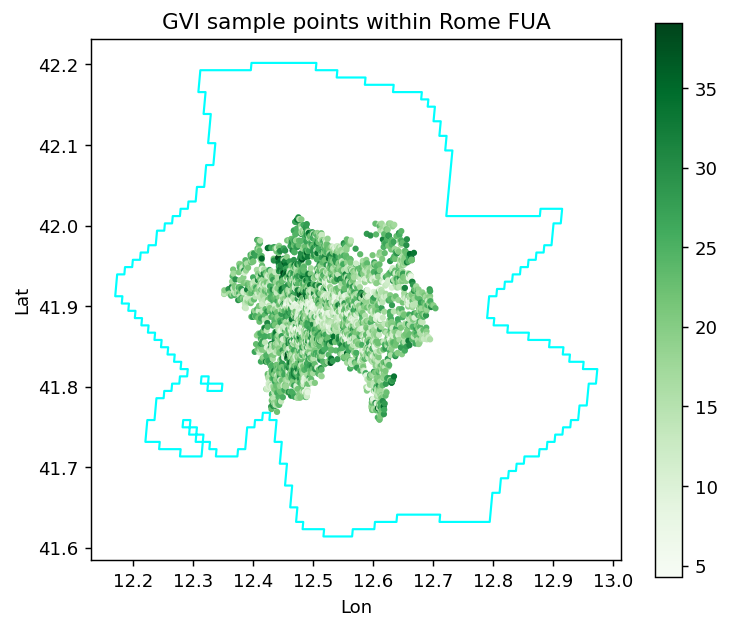

In [6]:
# Check 
import numpy as np
import matplotlib.pyplot as plt

print("CRS check:") # always checking CRS
print("  gvi_gdf.crs =", gvi_gdf.crs)
print("  FUA.crs      =", fua.to_crs("EPSG:4326").crs)

# checking how many points before and after the the clip
n_raw  = len(pd.read_csv(p_GVI / "gvi_Rome.csv"))
n_keep = len(gvi_gdf)
print(f"Points kept inside FUA: {n_keep} / {n_raw}  ({100*n_keep/n_raw:.1f}%)")
# as a %

# how many nas, min/median/max value of gvi 
na_gvi = gvi_gdf["gvi"].isna().sum()
gvi_min, gvi_p50, gvi_max = gvi_gdf["gvi"].min(), gvi_gdf["gvi"].median(), gvi_gdf["gvi"].max()
print(f"GVI: min={gvi_min:.2f}, median={gvi_p50:.2f}, max={gvi_max:.2f}, NaNs={na_gvi}")

# detecting the scale of the gvi (0–1 vs 0–100) 
# (just a way to do it in general, we knew already since we inspected the dataset before)
if gvi_max <= 1.5:
    print("GVI appears to be in 0–1 scale.")
elif gvi_max <= 100 + 1e-6:
    print("GVI appears to be in 0–100 scale (we could need to divide by 100 later).")
else:
    print("WARNING: GVI scale looks unusual")

# any obvious duplicates (same lon/lat)
dups = (gvi_gdf
        .assign(lon=lambda d: d.geometry.x.round(6),
                lat=lambda d: d.geometry.y.round(6))
        .duplicated(subset=["lon","lat"])
        .sum())
print("Approx duplicate coords (rounded to 1e-6):", int(dups)) # counts duplicated coordinate pairs

# quick map
fua_4326 = fua.to_crs("EPSG:4326")
ax = fua_4326.plot(edgecolor="cyan", facecolor="none", linewidth=1.2, figsize=(6,5))
gvi_gdf.plot(ax=ax, markersize=6, column="gvi", cmap="Greens", legend=True)
ax.set_title("GVI sample points within Rome FUA")
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
plt.tight_layout(); plt.show()

# if many points were dropped, boundary-inclusive join
if n_keep < 0.5 * n_raw:
    print("\nMany points were dropped. 'intersects' join:")
    print("gvi_gdf = gvi_gdf.sjoin(fua_4326[['geometry']], predicate='intersects').drop(columns='index_right')")

**Building Municipi (OSM), dissolving to 15 units + “Fuori Municipi”**

In [7]:
import re
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.ops import unary_union
import osmnx as ox

# keeping GVI both as 1–100 and 0–1 
gvi_gdf["gvi_0_1"] = gvi_gdf["gvi"] / 100.0

# OSMnx settings
ox.settings.use_cache = True
ox.settings.log_console = False

place_name = "Roma, Italia"
city_poly = ox.geocode_to_gdf(place_name).to_crs("EPSG:4326").geometry.iloc[0]

# features_from_polygon 
tags = {"boundary": "administrative", "admin_level": "10"}
muni = ox.features_from_polygon(city_poly, tags=tags)

# keeping only polygonal features, in WGS84
muni = muni[muni.geometry.type.isin(["Polygon", "MultiPolygon"])].copy()
muni = muni.to_crs("EPSG:4326")

# filtering again (admin_level is a string in OSM, here it's 10, I checked on wikipedia)
if "admin_level" in muni.columns:
    muni = muni[muni["admin_level"].astype(str) == "10"]
if "boundary" in muni.columns:
    muni = muni[muni["boundary"] == "administrative"]

# clipping to Rome FUA
muni = gpd.overlay(
    muni[["geometry","name","name:it","short_name","ref"]].reset_index(drop=True),
    fua[["geometry"]].to_crs("EPSG:4326"),
    how="intersection"
)

# readable name for each municipio from whatever name fields exist in polygons
def _pick_name(row):
    for k in ("name:it", "name", "short_name", "ref"):
        val = row.get(k, None)
        if isinstance(val, str) and val.strip():
            return val.strip()
    return "Municipio" # using Italian name 

# creating the column
muni["muni_name"] = muni.apply(_pick_name, axis=1)

# dissolving by name so each municipio is a single polygon
muni = muni.dissolve(by="muni_name", as_index=False, aggfunc="first").reset_index(drop=True)

# stable integer ID
muni = muni.reset_index(drop=True)
muni["muni_id"] = muni.index + 1

print(f"Found {len(muni)} municipios (expected 15).")
print(sorted(muni["muni_name"].unique())) # we should see 15 Municipio

Found 15 municipios (expected 15).
['Municipio Roma I', 'Municipio Roma II', 'Municipio Roma III', 'Municipio Roma IV', 'Municipio Roma IX', 'Municipio Roma V', 'Municipio Roma VI', 'Municipio Roma VII', 'Municipio Roma VIII', 'Municipio Roma X', 'Municipio Roma XI', 'Municipio Roma XII', 'Municipio Roma XIII', 'Municipio Roma XIV', 'Municipio Roma XV']


/var/folders/jr/55yqw22n1_n4th6my741s7g00000gn/T/ipykernel_59485/1349175204.py:13: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  muni_union = gpd.GeoDataFrame(geometry=[muni.unary_union], crs=muni.crs)


,Unnamed: 0,lon,lat,lcz_filter_v3,gvi,geometry,gvi_0_1,index_right,muni_id,muni_name
0,1,12.351697,41.915007,6,18.299756,POINT (12.3517 41.91501),0.182998,12,13,Municipio Roma XIII
1,2,12.352030,41.915886,6,14.004485,POINT (12.35203 41.91589),0.140045,12,13,Municipio Roma XIII
2,3,12.352051,41.919640,6,19.536704,POINT (12.35205 41.91964),0.195367,12,13,Municipio Roma XIII
3,4,12.359077,41.921091,6,29.173072,POINT (12.35908 41.92109),0.291731,12,13,Municipio Roma XIII
4,5,12.360293,41.915526,6,17.205097,POINT (12.36029 41.91553),0.172051,12,13,Municipio Roma XIII


Points in 'Fuori Municipi (FUA)': 204
Truly unmatched points (outside FUA or geometry glitch): 0


,muni_id,muni_name,count,mean,median,p10,p90,gvi_mean_0_1,gvi_median_0_1,area_km2,pts_per_km2
0,0,Fuori Municipi (FUA),204,20.850505,20.807849,14.024414,28.784014,0.208505,0.208078,1519.994441,0.134211
1,1,Municipio Roma I,310,15.710084,13.669406,7.591020,26.898145,0.157101,0.136694,20.091872,15.429125
2,2,Municipio Roma II,222,19.654512,19.070607,10.337241,30.129177,0.196545,0.190706,19.686091,11.276997
3,3,Municipio Roma III,232,20.589272,21.037889,12.480792,28.602860,0.205893,0.210379,97.823844,2.371610
4,4,Municipio Roma IV,291,18.796327,19.006146,9.819673,27.390055,0.187963,0.190061,48.888127,5.952365
5,5,Municipio Roma V,243,16.608336,15.758318,9.573555,24.867102,0.166083,0.157583,27.095594,8.968248
6,6,Municipio Roma VI,339,19.103894,19.373931,12.542369,25.543366,0.191039,0.193739,105.091505,3.225760
7,7,Municipio Roma VII,348,17.257253,17.306379,8.951908,25.545704,0.172573,0.173064,47.133068,7.383351
8,8,Municipio Roma VIII,233,20.586903,20.903788,11.586196,28.160852,0.205869,0.209038,47.317076,4.924226
9,9,Municipio Roma IX,317,21.118490,21.433552,12.316310,28.786089,0.211185,0.214336,174.877964,1.812693


Min samples per municipio (1–15): 1


Text(37.38888888888889, 0.5, 'Lat')

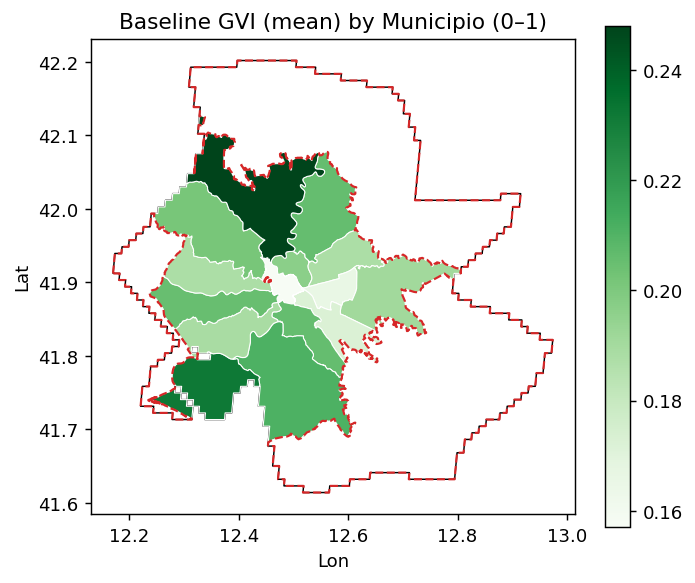

In [8]:
# making muni_id matches the Roman numeral (I..XV -> 1..15) 
roman_map = {"I":1,"II":2,"III":3,"IV":4,"V":5,"VI":6,"VII":7,"VIII":8,
             "IX":9,"X":10,"XI":11,"XII":12,"XIII":13,"XIV":14,"XV":15}
rom = muni["muni_name"].str.extract(r'([IVXLCDM]+)\s*$', expand=False)
muni["muni_id"] = rom.map(roman_map).astype(int)

# keeping one polygon per municipio (we dissolved them earlier but it's to double check)
muni = muni.dissolve(by=["muni_id","muni_name"], as_index=False)

# building the outside any Municipio but still in FUA and putting it as a category so the muni_id = 0 have still a category
# I think it's due to Vatican 
fua4326 = fua.to_crs("EPSG:4326")
muni_union = gpd.GeoDataFrame(geometry=[muni.unary_union], crs=muni.crs)
outside = gpd.overlay(fua4326[["geometry"]], muni_union, how="difference")

# if any leftover geometry, assigning a synthetic region id/name
extras = []
if not outside.empty:
    outside = outside.set_crs("EPSG:4326")
    outside["muni_id"] = 0
    outside["muni_name"] = "Fuori Municipi (FUA)"
    extras = [outside[["muni_id","muni_name","geometry"]]]

# combining Municipi + Outside into one regions layer
regions = pd.concat(
    [muni[["muni_id","muni_name","geometry"]]] + extras,
    ignore_index=True
).set_crs("EPSG:4326")

# spatial join GVI points to regions and aggregate (VERY IMPORTANT STEP) 
# for each GVI point (between 0 and 100), spatial join assigns the muni_id of the polygon it falls within
# so we have a point table with a Municipio tag for every point or 0 for Fuori Municipi 
gvi_in_regions = gvi_gdf.sjoin(regions[["muni_id","muni_name","geometry"]],
                               predicate="within", how="left")

display(gvi_in_regions.head())

# counting how many fall in the outside bucket (muni_id == 0) and how many truly have no match : it should be 0
n_outside = int((gvi_in_regions["muni_id"] == 0).sum()) if (0 in regions["muni_id"].values) else 0
n_unmatched = int(gvi_in_regions["muni_id"].isna().sum())
print(f"Points in 'Fuori Municipi (FUA)': {n_outside}")
print(f"Truly unmatched points (outside FUA or geometry glitch): {n_unmatched}")

# aggregating by municipio:
# computing, for each Municipio, the mean/median/quantiles of the GVI over all ppints inside it
# because each point is one pixel sample, the mean is a spatial average over the sampled pixels 
# then converting to the 0-1 modeling scale (not necessary actually because the cooling efficiency also takes GVI in 1-100)
reg_gvi = (gvi_in_regions
           .groupby(["muni_id","muni_name"], as_index=False)["gvi"]
           .agg(count="count",
                mean="mean",
                median="median",
                p10=lambda s: s.quantile(0.10),
                p90=lambda s: s.quantile(0.90)))

reg_gvi["gvi_mean_0_1"]   = reg_gvi["mean"]   / 100.0
reg_gvi["gvi_median_0_1"] = reg_gvi["median"] / 100.0

# area (km2) and sample density for all regions (Municipi + Outside) : area and sample density 
regions_m = regions.to_crs("EPSG:32633")  # metric CRS for Rome area
areas = regions_m.copy()
areas["area_km2"] = areas.geometry.area / 1e6
reg_gvi = reg_gvi.merge(areas[["muni_id","area_km2"]], on="muni_id", how="left")
reg_gvi["pts_per_km2"] = reg_gvi["count"] / reg_gvi["area_km2"] # we do this because we can have a different nbs of points in each Municipio 
# so mean could be biased toward denser-sampled areas

# Municipio 1..15 ascending 
reg_gvi = reg_gvi.sort_values(["muni_id","muni_name"], ascending=[True, True]).reset_index(drop=True)

# print
display(reg_gvi)
if (reg_gvi["muni_id"] > 0).any():
    print("Min samples per municipio (1–15):",
          int(reg_gvi.loc[reg_gvi["muni_id"]>0, "count"].min()))

# attaching stats back to polygons for a map (Municipi only) 
muni_gvi = muni.merge(reg_gvi[reg_gvi["muni_id"]>0],
                      on=["muni_id","muni_name"], how="left")

# Municipi choropleth + FUA outline, outside bucket separately
ax = fua4326.plot(edgecolor="k", facecolor="none", linewidth=0.8, figsize=(6,5))
muni_gvi.plot(ax=ax, column="gvi_mean_0_1", cmap="Greens",
              legend=True, edgecolor="white", linewidth=0.6)
if extras:
    outside.plot(ax=ax, facecolor="none", edgecolor="tab:red", linewidth=1.2, linestyle="--")
ax.set_title("Baseline GVI (mean) by Municipio (0–1)"); ax.set_xlabel("Lon"); ax.set_ylabel("Lat")

This is only informative, a descriptive analysis, after we need to do GVI to WBGT grid

In [9]:
# Summary of Municipio-level GVI (means), excluding muni_id == 0
mask = reg_gvi["muni_id"].between(1, 15)

s100 = reg_gvi.loc[mask, "mean"].dropna()          # 0–100 scale
s01  = reg_gvi.loc[mask, "gvi_mean_0_1"].dropna()  # 0–1 scale

def summarize(s):
    return pd.Series({
        "min":    s.min(),
        "Q1":     s.quantile(0.25),
        "median": s.median(),
        "mean":   s.mean(),
        "Q3":     s.quantile(0.75),
        "max":    s.max(),
        "sd":     s.std(ddof=1)
    })

summary_table = pd.concat(
    [summarize(s100), summarize(s01)],
    axis=1
)
summary_table.columns = ["GVI (0–100)", "GVI (0–1)"]
summary_table = summary_table.round(2)

display(summary_table)

,GVI (0–100),GVI (0–1)
min,15.71,0.16
Q1,18.79,0.19
median,19.65,0.20
mean,19.72,0.20
Q3,20.59,0.21
max,24.79,0.25
sd,2.34,0.02


In [10]:
# getting rid of Ostia
MIN_SAMPLES = 10
weak   = reg_gvi["count"] < MIN_SAMPLES
exclude_ids = set(reg_gvi.loc[weak, "muni_id"].astype(int))

reg_gvi_ok = (reg_gvi
              .loc[~weak & (reg_gvi["muni_id"] > 0),
                   ["muni_id","muni_name","gvi_mean_0_1"]]
              .copy())

In [11]:
# Municipi and LCZ to WBGT ref grid
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject
from rasterio.enums import Resampling
import geopandas as gpd
from pathlib import Path

# function to open raster, clip it to FUA, return float array with nas outside FUA
def read_and_mask_to_fua(raster_path: Path, fua_gdf: gpd.GeoDataFrame):
    with rasterio.open(raster_path) as src:
        fua_in_raster_crs = fua_gdf.to_crs(src.crs)
        geoms = [g for g in fua_in_raster_crs.geometry if g is not None]
        if not geoms:
            raise ValueError("FUA geometry is empty or invalid.")
        out_ma, out_transform = rio_mask(src, geoms, crop=True, filled=False)

        data = out_ma[0].astype("float32")
        m = np.ma.getmaskarray(out_ma[0])
        data[m] = np.nan

        nod = src.nodata if src.nodata is not None else 0.0
        data[data == nod] = np.nan

        out_meta = src.meta.copy()
        out_meta.update({
            "height": data.shape[0],
            "width":  data.shape[1],
            "transform": out_transform,
            "dtype": "float32"
        })
        return data, out_transform, src.crs, out_meta

# this takes other raster and put it on the exact same grid as ref (as before)
def ensure_on_reference_grid_nearest(src_path: Path, ref_meta, ref_data_shape, fua_gdf: gpd.GeoDataFrame):
    """clipping src raster to FUA and resampling to the reference grid, preserving NaNs."""
    src_data, src_transform, src_crs, src_meta = read_and_mask_to_fua(src_path, fua_gdf)

    same_grid = (
        (src_meta["crs"] == ref_meta["crs"]) and
        (src_meta["transform"] == ref_meta["transform"]) and
        (src_data.shape == ref_data_shape)
    )
    if same_grid:
        return src_data, ref_meta

    dst = np.full(ref_data_shape, np.nan, dtype="float32")
    reproject(
        source=src_data,
        destination=dst,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"],
        dst_crs=ref_meta["crs"],
        resampling=Resampling.nearest,
        src_nodata=0.0,      # careful!! 
        dst_nodata=np.nan,
    )
    return dst, ref_meta

In [12]:
# applying the two functions we defined
# Municipi to WBGT grid
muni_ref = muni.to_crs(ref_meta["crs"])
shapes = [(geom, int(mid)) for geom, mid in zip(muni_ref.geometry, muni_ref["muni_id"])]
muni_on_ref = rasterio.features.rasterize(
    shapes=shapes, out_shape=ref_data.shape, transform=ref_meta["transform"],
    fill=0, dtype="int32"
)

In [13]:
# new masks
MUNI_PIX = CITY_MASK & (muni_on_ref > 0) # second mask for all the Municipi level aggregation

In [14]:
import numpy as np
from scipy import ndimage as ndi

# using HAZ_MASK 
haz_mask = np.isfinite(ref_data)

# filling only inside hazard
work = np.where(haz_mask, lcz_on_ref, np.nan)
missing_inside = np.isnan(work) & haz_mask

if missing_inside.any():
    valid = (~np.isnan(work)) & haz_mask
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]

# check
lcz_on_ref = np.where(haz_mask, work, 0).astype("int16")
assert ((lcz_on_ref > 0) | (~haz_mask)).all(), "Still have LCZ==0 inside hazard—check inputs."
print("OK: LCZ now defined for all hazard pixels.")

OK: LCZ now defined for all hazard pixels.


**GVI to WBGT grid (cell means; nearest fill)**

Everything on WBGT grid. We map points to cells, average if multiple points fall in the same cell, and fill empty cells by nearest neighbor so every hazard pixel has a GVI.

In [15]:
import numpy as np
from rasterio.transform import rowcol
from scipy import ndimage as ndi

# ensuring CRS match (ref grid is EPSG:4326)
if str(gvi_gdf.crs) != str(ref_meta["crs"]):
    gvi_xy = gvi_gdf.to_crs(ref_meta["crs"]).geometry
else:
    gvi_xy = gvi_gdf.geometry

# mapping each GVI point to WBGT ref grid
rows, cols = rowcol(ref_meta["transform"],
                    gvi_xy.x.values,
                    gvi_xy.y.values,
                    op=np.floor)
rows = rows.astype(int); cols = cols.astype(int)

h, w = HGT, WDT
inside = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
rows, cols = rows[inside], cols[inside]
vals = (gvi_gdf.loc[inside, "gvi"].to_numpy(float) / 100.0)  # 0–1 scale

# binning by cell: mean of all samples in each cell
sum_grid = np.zeros((h, w), float)
cnt_grid = np.zeros((h, w), float)
np.add.at(sum_grid, (rows, cols), vals)
np.add.at(cnt_grid, (rows, cols), 1.0)
gvi_on_ref = np.divide(sum_grid, cnt_grid, out=np.full((h, w), np.nan), where=cnt_grid > 0)

# filling missing only within the hazard/city footprint
missing = HAZ_MASK & ~np.isfinite(gvi_on_ref)
if missing.any():
    valid = HAZ_MASK & np.isfinite(gvi_on_ref)
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    gvi_on_ref[missing] = gvi_on_ref[iy[missing], ix[missing]]

# kepping NaN outside hazard 
gvi_on_ref[~HAZ_MASK] = np.nan

print("gvi_on_ref built. Finite share on city mask:",
      float(np.isfinite(gvi_on_ref)[CITY_MASK].mean()))

gvi_on_ref built. Finite share on city mask: 1.0


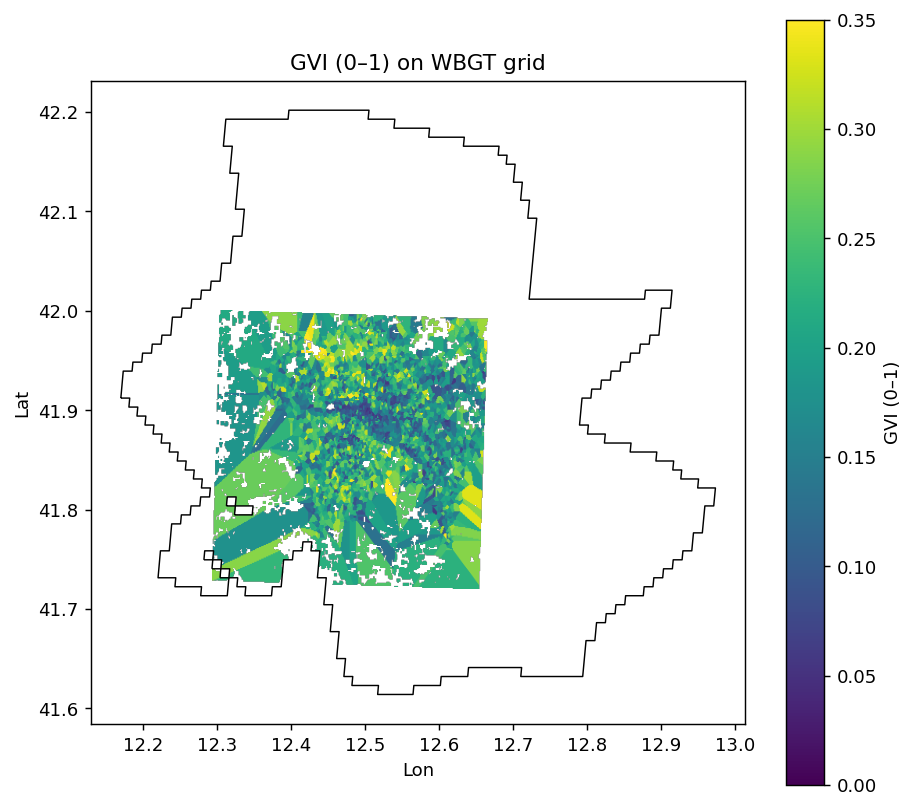

In [16]:
left, bottom, right, top = array_bounds(HGT, WDT, ref_meta["transform"])
extent = (left, right, bottom, top)

plt.figure(figsize=(7.2,6.4))
im = plt.imshow(gvi_on_ref, origin="upper", extent=extent, vmin=0, vmax=0.35)
cb = plt.colorbar(im); cb.set_label("GVI (0–1)")
fua_4326.boundary.plot(ax=plt.gca(), color="k", lw=0.8)
plt.title("GVI (0–1) on WBGT grid")
plt.xlabel("Lon"); plt.ylabel("Lat"); plt.tight_layout(); plt.show()

**Municipi & LCZ on WBGT grid**

In [17]:
# getting rid of Ostia
MIN_SAMPLES = 10
weak   = reg_gvi["count"] < MIN_SAMPLES
exclude_ids = set(reg_gvi.loc[weak, "muni_id"].astype(int))

reg_gvi_ok = (reg_gvi
              .loc[~weak & (reg_gvi["muni_id"] > 0),
                   ["muni_id","muni_name","gvi_mean_0_1"]]
              .copy())

In [18]:
import rasterio as rio
from rasterio.warp import reproject
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio.mask import mask as rio_mask
from scipy import ndimage as ndi
import numpy as np
import pandas as pd

# rasterising Municipi to WBGT grid
muni_ref = muni.to_crs(ref_meta["crs"])
shapes = [(geom, int(mid)) for geom, mid in zip(muni_ref.geometry, muni_ref["muni_id"])]
muni_on_ref = rasterize(
    shapes=shapes,
    out_shape=(HGT, WDT),
    transform=ref_meta["transform"],
    fill=0,
    dtype="int32"
)

# LCZ onto WBGT grid (nearest — categorical)
def ensure_on_reference_grid_nearest(src_path, ref_meta, ref_shape, fua_gdf):
    with rio.open(src_path) as src:
        fua_in_raster_crs = fua_gdf.to_crs(src.crs)
        out_ma, out_transform = rio_mask(src, list(fua_in_raster_crs.geometry), crop=True, filled=False)
        data = out_ma[0].astype("float32")
        mask = np.ma.getmaskarray(out_ma[0])
        data[mask] = np.nan
        src_meta = src.meta.copy()
        src_meta.update(height=data.shape[0], width=data.shape[1], transform=out_transform)

    same = (
        src_meta["crs"] == ref_meta["crs"]
        and src_meta["transform"] == ref_meta["transform"]
        and data.shape == ref_shape
    )
    if same:
        return data, ref_meta

    dst = np.full(ref_shape, np.nan, dtype="float32")
    reproject(
        source=data, destination=dst,
        src_transform=src_meta["transform"], src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"], dst_crs=ref_meta["crs"],
        resampling=Resampling.nearest,
        src_nodata=np.nan, dst_nodata=np.nan,
    )
    return dst, ref_meta

lcz_on_ref, _ = ensure_on_reference_grid_nearest(
    p_LCZ / "lcz_filter_v3.tif", ref_meta, (HGT, WDT), fua
)

# LCZ inside the hazard footprint (treating 0 and NaN as invalid)
haz_mask = np.isfinite(ref_data)            # where the hazard/city grid is defined

lcz_raw = lcz_on_ref.astype("float32")      
# valid = LCZ in 1..17 AND inside hazard
valid = np.isfinite(lcz_raw) & (lcz_raw > 0) & haz_mask
invalid = (~valid) & haz_mask

if not valid.any():
    raise RuntimeError("No valid LCZ classes inside the hazard footprint to fill from.")

# nearest-neighbor fill for invalid hazard pixels
_, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)

lcz_filled = lcz_raw.copy()
lcz_filled[invalid] = lcz_raw[iy[invalid], ix[invalid]]

# Outside hazard: set to 0
lcz_filled[~haz_mask] = 0.0

lcz_on_ref = lcz_filled.astype("int16")

bad_inside = ((lcz_on_ref <= 0) & haz_mask).sum()
assert bad_inside == 0, f"Still have {bad_inside} LCZ<=0 pixels inside hazard—check inputs."

**Municipio-level GVI (population-weighted)**

Average where people live, not just area

In [19]:
def wmean(x, w):
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.average(x[m], weights=w[m]) if m.any() else np.nan

mask = np.isfinite(gvi_on_ref) & np.isfinite(pop_on_ref) & (muni_on_ref >= 0)
x = gvi_on_ref[mask]
w = pop_on_ref[mask]
ids = muni_on_ref[mask].astype(int)

den = np.bincount(ids, weights=w, minlength=int(muni_on_ref.max())+1)
num = np.bincount(ids, weights=w*x, minlength=int(muni_on_ref.max())+1)
gvi_pw = np.divide(num, den, out=np.full_like(num, np.nan), where=den>0)

reg_gvi_grid = (pd.DataFrame({"muni_id": np.arange(len(gvi_pw), dtype=int),
                              "gvi_mean_0_1_popw": gvi_pw})
                .merge(muni[["muni_id","muni_name"]], on="muni_id", how="right")
                .sort_values("muni_id"))

display(reg_gvi_grid.head())

,muni_id,gvi_mean_0_1_popw,muni_name
0,1,0.151627,Municipio Roma I
1,2,0.187751,Municipio Roma II
2,3,0.210380,Municipio Roma III
3,4,0.179691,Municipio Roma IV
4,5,0.160880,Municipio Roma V


In [20]:
mask15 = reg_gvi_grid["muni_id"].between(1, 15)
s = reg_gvi_grid.loc[mask15, "gvi_mean_0_1_popw"].dropna()
summary = pd.Series({
    "min": s.min(), "Q1": s.quantile(0.25), "median": s.median(),
    "mean": s.mean(), "Q3": s.quantile(0.75), "max": s.max(), "sd": s.std(ddof=1)
}).round(3)
display(pd.DataFrame(summary, columns=["GVI pop-weighted (0–1)"]))

,GVI pop-weighted (0–1)
min,0.152
Q1,0.178
median,0.196
mean,0.192
Q3,0.207
max,0.235
sd,0.022


**Excluding weakly-sampled Municipi**

If a Municipio has too few GVI points, noisy baseline. We exclude (e.g., Ostia) from policy aggregation to avoid distortions.

In [21]:
# point coverage per municipio (from the original spatial join)
gvi_in_regions = gvi_gdf.sjoin(
    gpd.GeoDataFrame(regions[["muni_id","muni_name","geometry"]],
                     geometry="geometry", crs="EPSG:4326"),
    predicate="within", how="left"
)

pt_counts = (gvi_in_regions.groupby("muni_id", as_index=False)["gvi"]
             .size().rename(columns={"size":"count"}))

areas = regions.to_crs("EPSG:32633").copy()
areas["area_km2"] = areas.geometry.area / 1e6

coverage = (reg_gvi_grid
            .merge(pt_counts, on="muni_id", how="left")
            .merge(areas[["muni_id","area_km2"]], on="muni_id", how="left"))
coverage["count"] = coverage["count"].fillna(0).astype(int)
coverage["pts_per_km2"] = coverage["count"] / coverage["area_km2"]

MIN_SAMPLES = 10
exclude_ids = set(coverage.loc[(coverage["count"] < MIN_SAMPLES) | coverage["count"].isna(), "muni_id"].astype(int)) | {10}  # drop Ostia
muni_ok = muni.loc[~muni["muni_id"].isin(exclude_ids)].copy()

# final baseline table used for policy
reg_gvi_ok = (coverage.loc[coverage["muni_id"].between(1,15) & (~coverage["muni_id"].isin(exclude_ids)),
                           ["muni_id","muni_name","gvi_mean_0_1_popw","count","pts_per_km2"]]
                      .rename(columns={"gvi_mean_0_1_popw":"gvi_mean_0_1"})
                      .sort_values("muni_id")
                      .reset_index(drop=True))
display(reg_gvi_ok)

,muni_id,muni_name,gvi_mean_0_1,count,pts_per_km2
0,1,Municipio Roma I,0.151627,310,15.429125
1,2,Municipio Roma II,0.187751,222,11.276997
2,3,Municipio Roma III,0.210380,232,2.371610
3,4,Municipio Roma IV,0.179691,291,5.952365
4,5,Municipio Roma V,0.160880,243,8.968248
5,6,Municipio Roma VI,0.180435,339,3.225760
6,7,Municipio Roma VII,0.173985,348,7.383351
7,8,Municipio Roma VIII,0.196311,233,4.924226
8,9,Municipio Roma IX,0.208151,317,1.812693
9,11,Municipio Roma XI,0.206099,121,1.742867


## Needs-based tree policy (TARGET & CAP)

In [22]:
# 0–1 scale
TARGET = 0.21   # Q3 of current Municipi GVI
CAP    = 0.12   # max uplift per municipio (12 pp)

# Baseline per Municipio
gvi0_by_muni = {int(r.muni_id): float(r.gvi_mean_0_1) for r in reg_gvi_ok.itertuples()}

# Needs
dGVI_needs = {mid: min(max(0.0, TARGET - g0), CAP) for mid, g0 in gvi0_by_muni.items()}

# LUT over rasterized Municipi
lut = np.full(int(muni["muni_id"].max()) + 1, np.nan, dtype=float)
for mid, d in dGVI_needs.items():
    lut[int(mid)] = d

# NaN for plotting, 0 outside scope
MUNI_PIX = HAZ_MASK & (muni_on_ref > 0)
dGVI_map_plot  = np.where(MUNI_PIX, lut[muni_on_ref], np.nan)
dGVI_map_model = np.where(np.isfinite(dGVI_map_plot), dGVI_map_plot, 0.0)

# City diagnostic (population-weighted over Municipi scope)
w = np.where(MUNI_PIX, pop_on_ref, 0.0)
dGVI_city_pw = (np.nansum(dGVI_map_model * w) / np.nansum(w)) if np.nansum(w) > 0 else np.nan
print(f"[Diag] Citywide ΔGVI (pop-weighted over Municipi): {dGVI_city_pw:.4f}")

[Diag] Citywide ΔGVI (pop-weighted over Municipi): 0.0210


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
0.0210 is a population-weighted citywide mean of the policy uplift, computed over pixels that lie inside any Municipio and have people. We averaged the per-pixel change in GVI using population in each pixel as the weight. Weights = pop_on_ref, scope = MUNI_PIX (the intersection of Municipi and city footprint, Statistic = sum(change in GVI * pop)/sum(pop). It reflects the change in GVI experienced by the average resident. It's on the 0-1 scale ie +2.1 points on the 1-100 GVI index.
</blockquote>

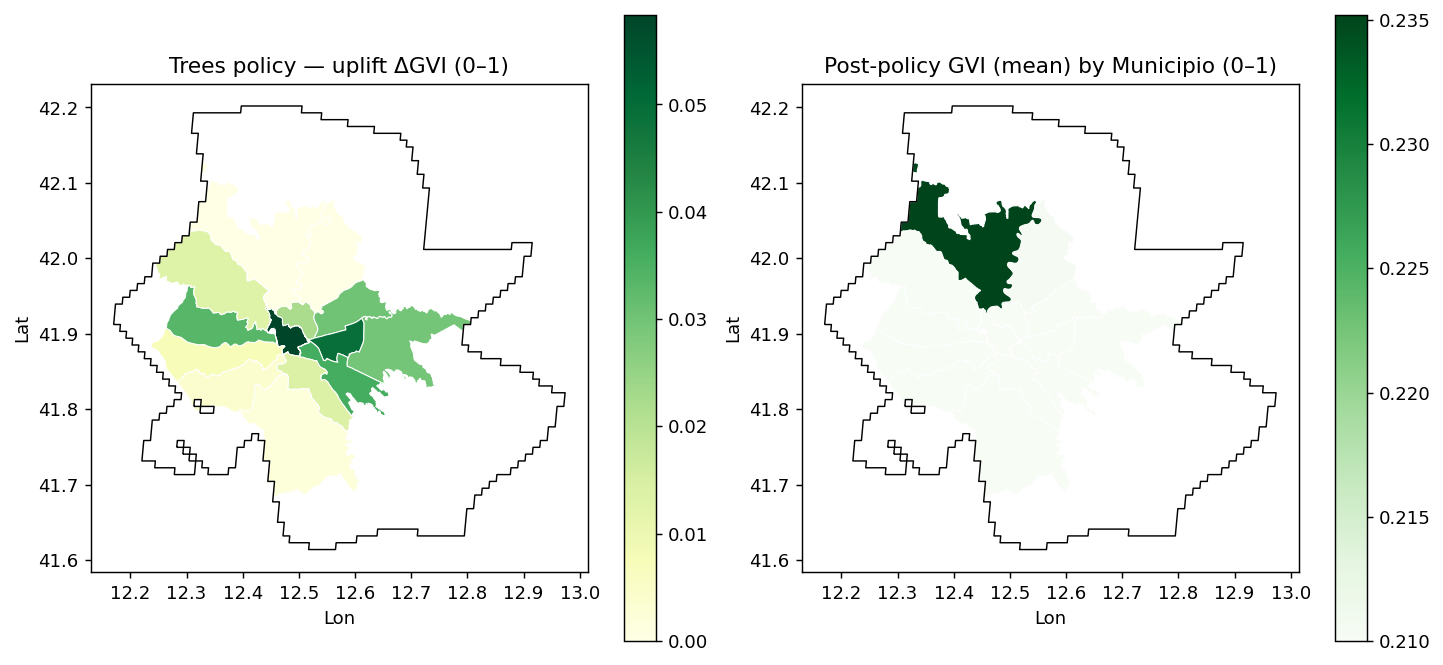

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(11,5), constrained_layout=True)

mt = muni_ok.merge(
    pd.DataFrame([{"muni_id": k, "dGVI": v} for k, v in dGVI_needs.items()]),
    on="muni_id", how="left"
).merge(reg_gvi_ok[["muni_id","muni_name","gvi_mean_0_1"]], on=["muni_id"], how="left")
mt["gvi_after"] = np.clip(mt["gvi_mean_0_1"] + mt["dGVI"].fillna(0.0), 0, 1)

fua_4326.boundary.plot(ax=ax[0], color="k", lw=0.8)
mt.plot(ax=ax[0], column="dGVI", cmap="YlGn", legend=True, edgecolor="white", linewidth=0.6)
ax[0].set_title("Trees policy — uplift ΔGVI (0–1)"); ax[0].set_xlabel("Lon"); ax[0].set_ylabel("Lat")

fua_4326.boundary.plot(ax=ax[1], color="k", lw=0.8)
mt.plot(ax=ax[1], column="gvi_after", cmap="Greens", legend=True, edgecolor="white", linewidth=0.6)
ax[1].set_title("Post-policy GVI (mean) by Municipio (0–1)"); ax[1].set_xlabel("Lon"); ax[1].set_ylabel("Lat")

plt.show()

In [24]:
trees_tbl = (reg_gvi_ok
             .merge(pd.DataFrame([{"muni_id": k, "dGVI": v} for k, v in dGVI_needs.items()]),
                    on="muni_id", how="left")
             .assign(dGVI=lambda d: d["dGVI"].fillna(0.0),
                     gvi_after=lambda d: np.clip(d["gvi_mean_0_1"] + d["dGVI"], 0, 1)))
trees_tbl = trees_tbl[["muni_id","muni_name","gvi_mean_0_1","dGVI","gvi_after","count","pts_per_km2"]]
display(trees_tbl.sort_values("muni_id"))

,muni_id,muni_name,gvi_mean_0_1,dGVI,gvi_after,count,pts_per_km2
0,1,Municipio Roma I,0.151627,0.058373,0.210000,310,15.429125
1,2,Municipio Roma II,0.187751,0.022249,0.210000,222,11.276997
2,3,Municipio Roma III,0.210380,0.000000,0.210380,232,2.371610
3,4,Municipio Roma IV,0.179691,0.030309,0.210000,291,5.952365
4,5,Municipio Roma V,0.160880,0.049120,0.210000,243,8.968248
5,6,Municipio Roma VI,0.180435,0.029565,0.210000,339,3.225760
6,7,Municipio Roma VII,0.173985,0.036015,0.210000,348,7.383351
7,8,Municipio Roma VIII,0.196311,0.013689,0.210000,233,4.924226
8,9,Municipio Roma IX,0.208151,0.001849,0.210000,317,1.812693
9,11,Municipio Roma XI,0.206099,0.003901,0.210000,121,1.742867


In [25]:
exclude = {10}  # drop Ostia
mask = trees_tbl["muni_id"].between(1, 15) & ~trees_tbl["muni_id"].isin(exclude)

total_01 = float(trees_tbl.loc[mask, "dGVI"].sum())
total_pts = total_01 * 100.0

print(f"Sum of needs across Municipi (0–1): {total_01:.6f}")
print(f"Sum of needs across Municipi (points on 1–100): {total_pts:.4f}")

Sum of needs across Municipi (0–1): 0.298932
Sum of needs across Municipi (points on 1–100): 29.8932


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">

- dGVI: per-Municipio uplift: how many extra GVI points (on the 0–1 scale) each Municipio gets under the policy.
  
- The sum of dGVI across Municipi gives us the change in GVI due to the policy that we will then use in the CBA: 0.298932 (0-1 scale), 29.8932 (1-100 scale). 

- Citywide ΔGVI (pop-weighted over Municipi): 0.0210 is the single citywide average uplift experienced by the average resident. It’s computed on the grid by weighting each pixel’s uplift by its population and then averaging across all Municipi pixels included in the policy. On the 0–100 index, that’s +2.1 points.
  
- They are different because citywide number is not the simple mean of the dGVI column. Heavily populated pixels/Municipi count more than lightly populated ones. So areas with many residents but small uplift can raise or decrease the citywide number, even if some Municipi get big dGVI.
  
- Some Municipi have dGVI = 0 because they’re already at/above the target: they enter the population-weighted average too.

- Any excluded Municipio (e.g., Ostia) doesn’t contribute to the citywide diagnostic, by design.
</blockquote>

**From Variation in GVI to variation of WBGT (by month and LCZ)**

In [26]:
from pathlib import Path

csv_path = p_CoolEff / "outer_2_wbgt_max.csv"
assert csv_path.exists(), f"Missing: {csv_path}"
df = pd.read_csv(csv_path)

# part before underscore for the city name (know it because inspected the data before)
city_token = df["UC_NM_MN"].astype(str).str.split("_", n=1, expand=True)[0].str.lower()
rome = df[city_token.isin(["rome", "roma"])].copy()

# keeping the needed col 
rome = rome[["month","lcz","coef"]]

# mapping LCZ names -> numeric codes (bc in the dataset there are names/not nb)
LCZ_NAME_TO_CODE = {
    "Compact highrise": 1,  "Compact midrise": 2,  "Compact lowrise": 3,
    "Open highrise": 4,     "Open midrise": 5,     "Open lowrise": 6,
    "Lightweight low-rise": 7, "Lightweight low rise": 7,
    "Large lowrise": 8,     "Sparsely built": 9,   "Heavy industry": 10,
    "Dense trees": 11,      "Scattered trees": 12, "Bush, scrub": 13,
    "Low plants": 14,       "Bare rock/paved": 15, "Bare soil/sand": 16,
    "Water": 17,
}
rome["lcz_code"] = rome["lcz"].map(lambda s: LCZ_NAME_TO_CODE.get(str(s).strip(), np.nan))
rome = rome.dropna(subset=["lcz_code"]).astype({"month":"int","coef":"float"})
rome["lcz_code"] = rome["lcz_code"].astype(int)

print("Rome WBGT-max coeffs:", rome.shape)
print(rome.head())

Rome WBGT-max coeffs: (84, 4)
      month              lcz      coef  lcz_code
8292      1  Compact lowrise -0.143709         3
8293      2  Compact lowrise -0.132441         3
8294      3  Compact lowrise -0.105711         3
8295      4  Compact lowrise -0.086007         3
8296      5  Compact lowrise -0.073829         3


**Cooling efficiency to monthly ΔWBGT on the WBGT grid (ref grid)**

In [27]:
# Cooling efficiency table (Rome, WBGT_max) to ΔWBGT (12×H×W) on ref grid 

import pandas as pd, numpy as np
from scipy import ndimage as ndi

# loading coefficients (°C per +1 GVI POINT on 0–100 scale)
df = pd.read_csv(p_CoolEff / "outer_2_wbgt_max.csv")
city_token = df["UC_NM_MN"].astype(str).str.split("_", n=1, expand=True)[0].str.lower()
rome = df.loc[city_token.isin(["rome","roma"]), ["month","lcz","coef"]].copy()
# SO WE WOULD NEED TO MULTIPLY BY 100!!

# mapping LCZ names to codes used in LCZ raster (1..17)
LCZ_NAME_TO_CODE = {
    "Compact highrise": 1,  "Compact midrise": 2,  "Compact lowrise": 3,
    "Open highrise": 4,     "Open midrise": 5,     "Open lowrise": 6,
    "Lightweight low-rise": 7, "Lightweight low rise": 7,
    "Large lowrise": 8,     "Sparsely built": 9,   "Heavy industry": 10,
    "Dense trees": 11,      "Scattered trees": 12, "Bush, scrub": 13,
    "Low plants": 14,       "Bare rock/paved": 15, "Bare soil/sand": 16, "Water": 17
}
rome["lcz_code"] = rome["lcz"].map(lambda s: LCZ_NAME_TO_CODE.get(str(s).strip(), np.nan))
rome = rome.dropna(subset=["lcz_code"]).astype({"month":"int","coef":"float"})
rome["lcz_code"] = rome["lcz_code"].astype(int)

# building monthly ΔWBGT on the WBGT grid
coef_lut = {(int(r.month), int(r.lcz_code)): float(r.coef) for r in rome.itertuples(index=False)}
months = range(1, 13)

# building LCZs built only (1..10) within the city/hazard footprint
HAZ_MASK = np.isfinite(ref_data)
built_mask = (lcz_on_ref >= 1) & (lcz_on_ref <= 10) & HAZ_MASK

# policy ΔGVI in POINTS (0–100)
dGVI_points = dGVI_map_model * 100.0  # zeros outside policy

max_lcz = int(np.nanmax(lcz_on_ref))
dWBGT_month = []
for m in months:
    lcz2coef = np.zeros(max_lcz + 1, dtype=float)
    for (mm, ll), cc in coef_lut.items():
        if mm == m and ll <= max_lcz:
            lcz2coef[ll] = cc
    c = lcz2coef[np.clip(lcz_on_ref, 0, max_lcz)]
    dWBGT = np.where(built_mask, c * dGVI_points, 0.0)  # °C change this month
    dWBGT_month.append(dWBGT.astype("float32"))

dWBGT_stack = np.stack(dWBGT_month, axis=0)  # shape (12, H, W)
print("ΔWBGT (°C) across months:", float(np.nanmin(dWBGT_stack)), "→", float(np.nanmax(dWBGT_stack)))

ΔWBGT (°C) across months: -0.968064546585083 → 0.0


Citywide ΔGVI (pop-weighted over Municipi) ≈ 1.98 points (= 0.0198 on 0–1 scale)
Share of population with ΔGVI>0: 76.0%


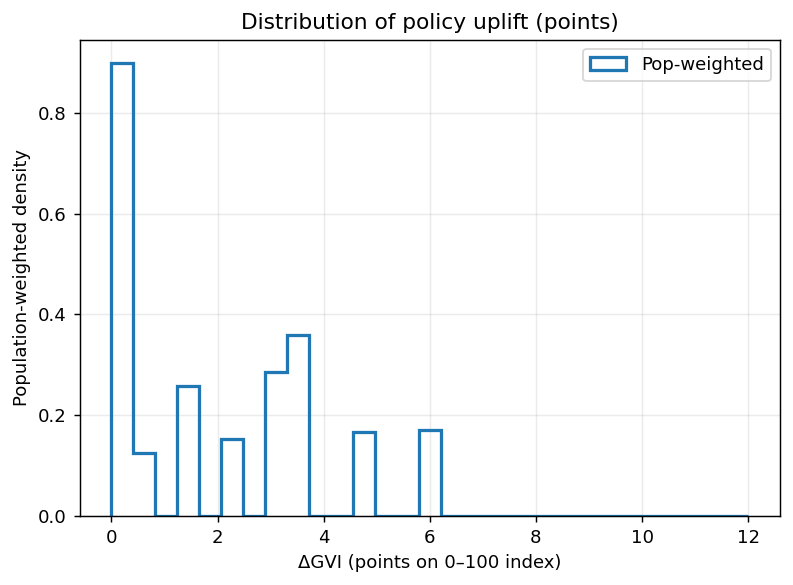

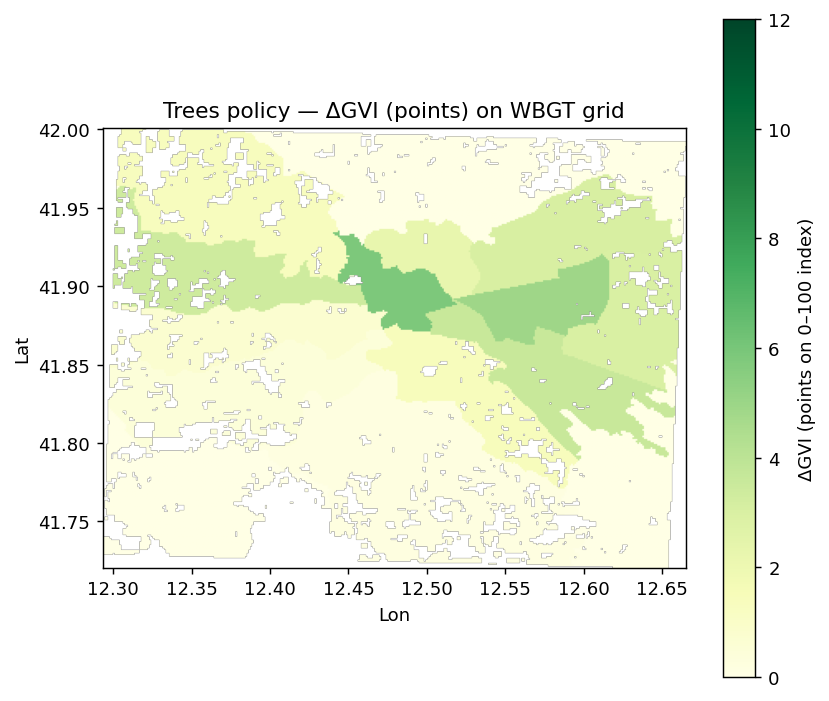

,muni_id,ΔGVI_points_popw,muni_name
0,1,5.837337,Municipio Roma I
1,5,4.911950,Municipio Roma V
2,7,3.601495,Municipio Roma VII
3,13,3.333220,Municipio Roma XIII
4,4,3.030893,Municipio Roma IV
5,6,2.956516,Municipio Roma VI
6,2,2.224850,Municipio Roma II
7,8,1.368906,Municipio Roma VIII
8,14,1.316533,Municipio Roma XIV
9,12,0.736448,Municipio Roma XII


In [28]:
# ΔGVI in "points" (0–100 index points)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

# Masks
POLICY = np.isfinite(dGVI_map_model) & CITY_MASK
WEIGHTS = np.where(POLICY, pop_on_ref, 0.0)

# pop-weighted mean uplift (points) — same diagnostic as before but in points
pw_mean_points = (np.nansum(dGVI_points * WEIGHTS) / np.nansum(WEIGHTS)) if np.nansum(WEIGHTS) > 0 else np.nan
print(f"Citywide ΔGVI (pop-weighted over Municipi) ≈ {pw_mean_points:.2f} points "
      f"(= {pw_mean_points/100:.4f} on 0–1 scale)")

# share of people with any uplift
share_people_uplift = float(np.nansum((dGVI_points > 0) * WEIGHTS) / np.nansum(WEIGHTS)) if np.nansum(WEIGHTS)>0 else np.nan
print(f"Share of population with ΔGVI>0: {share_people_uplift:.1%}")

# histogram (population-weighted, policy scope)
m = POLICY & np.isfinite(dGVI_points) & (WEIGHTS > 0)
v = dGVI_points[m].ravel(); w = WEIGHTS[m].ravel()
bins = np.linspace(0, max(12, np.nanmax(v)), 30)  # CAP is 12 points
plt.figure(figsize=(6.2,4.6))
plt.hist(v, bins=bins, weights=w, histtype="step", linewidth=1.8, density=True, label="Pop-weighted")
plt.xlabel("ΔGVI (points on 0–100 index)"); plt.ylabel("Population-weighted density")
plt.title("Distribution of policy uplift (points)")
plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()

# map (points)
left, bottom, right, top = array_bounds(HGT, WDT, ref_meta["transform"])
extent = (left, right, bottom, top)
plt.figure(figsize=(6.6,5.5))
im = plt.imshow(np.where(CITY_MASK, dGVI_points, np.nan), origin="upper", extent=extent, vmin=0, vmax=12, cmap="YlGn")
cb = plt.colorbar(im); cb.set_label("ΔGVI (points on 0–100 index)")
plt.title("Trees policy — ΔGVI (points) on WBGT grid")
plt.xlabel("Lon"); plt.ylabel("Lat"); plt.tight_layout(); plt.show()

# Municipio table in points
if 'muni_ok' in globals():
    ids = muni_on_ref[POLICY].astype(int)
    w   = WEIGHTS[POLICY]
    x   = dGVI_points[POLICY]
    # pop-weighted mean ΔGVI (points) by municipio
    den = np.bincount(ids, weights=w)
    num = np.bincount(ids, weights=w*x)
    by_muni = pd.DataFrame({
        "muni_id": np.arange(len(den), dtype=int),
        "ΔGVI_points_popw": np.divide(num, den, out=np.full_like(num, np.nan), where=den>0)
    })
    out = (by_muni.merge(muni_ok[["muni_id","muni_name"]], on="muni_id", how="inner")
                  .sort_values("ΔGVI_points_popw", ascending=False))
    display(out.reset_index(drop=True).head(10))

Coefficients say how many °C cooler per +1 GVI point for each month×LCZ. Multiplying by policy’s ΔGVI (in points) gives a monthly cooling map. Careful: we zero it outside built areas.

**Bridge to UrbClim daily grid and build the hazard multiplier f**

In [29]:
# here comes the difficult part
# we want to turn the LCZ x month cooling coeff + change in GVI into a per-pixel hazard multiplier and then rerun CLIMADA
import numpy as np, xarray as xr
import rasterio, pandas as pd
from affine import Affine
from rasterio.warp import reproject
from rasterio.enums import Resampling

THRESH = 28.0                 # WBGT hot-day threshold (°C)
HOT_MONTHS = [6, 7, 8, 9]     # months that matter for heat mortality
MIN_F, MAX_F = 0.4, 1.0       # clamp for numerical stability / realism

# daily UrbClim WBGT on its native grid 
try:
    ds
    da = ds[[v for v in ds.data_vars if v.lower() in ("wbgt","wbgt_max","wbgtmax","wbgt_maximum")][0]]
except Exception:
    nc_files = sorted(p_UrbClim.glob("WBGT_year_daily_max_*.nc"))
    assert nc_files, f"No UrbClim files at {p_UrbClim}"
    ds = xr.open_mfdataset(nc_files, combine="by_coords", decode_times=True, chunks={"time": 90})
    cand = ("wbgt_max","WBGT_max","wbgt","WBGT")
    vname = next((v for v in cand if v in ds.data_vars), None)
    assert vname, f"No WBGT-like variable. Available: {list(ds.data_vars)}"
    da = ds[vname]

x_uc = ds["x"].values; y_uc = ds["y"].values
dx_uc = float(np.diff(x_uc).mean()); dy_uc = float(np.diff(y_uc).mean())
transform_uc = (Affine.translation(float(x_uc.min()) - dx_uc/2,
                                   float(y_uc.min()) - dy_uc/2)
                * Affine.scale(dx_uc, dy_uc))

Hh, Ww = ref_data.shape

#  built and policy masks to UrbClim 
built_mask_ref = ((lcz_on_ref >= 1) & (lcz_on_ref <= 10) & np.isfinite(ref_data)).astype("uint8")
built_uc = np.zeros((len(y_uc), len(x_uc)), dtype="uint8")
reproject(
    source=built_mask_ref, destination=built_uc,
    src_transform=ref_meta["transform"], src_crs=ref_meta["crs"],
    dst_transform=transform_uc,          dst_crs=rasterio.crs.CRS.from_epsg(3035),
    resampling=Resampling.nearest, src_nodata=0, dst_nodata=0
)

policy_mask_ref = np.isfinite(dGVI_map_model).astype("uint8")  # Municipi scope
policy_uc = np.zeros_like(built_uc, dtype="uint8")
reproject(
    source=policy_mask_ref, destination=policy_uc,
    src_transform=ref_meta["transform"], src_crs=ref_meta["crs"],
    dst_transform=transform_uc,          dst_crs=rasterio.crs.CRS.from_epsg(3035),
    resampling=Resampling.nearest, src_nodata=0, dst_nodata=0
)

# reprojecting monthly ΔWBGT (built earlier on ref grid) to UrbClim 
def _to_uc(layer_2d: np.ndarray) -> np.ndarray:
    dst = np.full((len(y_uc), len(x_uc)), np.nan, dtype="float32")
    reproject(
        source=layer_2d.astype("float32"), destination=dst,
        src_transform=ref_meta["transform"], src_crs=ref_meta["crs"],
        dst_transform=transform_uc,          dst_crs=rasterio.crs.CRS.from_epsg(3035),
        resampling=Resampling.bilinear, src_nodata=np.nan, dst_nodata=np.nan
    )
    return dst

months = np.arange(1, 13, dtype=int)
dWBGT_uc = np.stack([_to_uc(dWBGT_stack[m-1]) for m in months], axis=0).astype("float32")
# zero outside built or outside policy
dWBGT_uc = np.where((built_uc[None, :, :] == 1) & (policy_uc[None, :, :] == 1), dWBGT_uc, 0.0).astype("float32")

# turning daily WBGT to expected hot-days (E0/E1) on UrbClim 
E0 = np.zeros((len(y_uc), len(x_uc)), dtype="float32")
E1 = np.zeros_like(E0)

for m in HOT_MONTHS:
    da_m = da.sel(time=(ds["time"].dt.month == m))
    # baseline hot-day probability per calendar day, summed => expected hot-days that month
    prob0_m = (da_m > THRESH).groupby("time.day").mean("time", skipna=True)
    e0_m = prob0_m.sum("day")
    # after trees: shift threshold by ΔWBGT for that month
    delta_m = xr.DataArray(dWBGT_uc[m-1], coords={"y": ds["y"], "x": ds["x"]}, dims=("y","x"))
    prob1_m = (da_m > (THRESH - delta_m)).groupby("time.day").mean("time", skipna=True)
    e1_m = prob1_m.sum("day")

    E0 += np.nan_to_num(e0_m.values, nan=0.0).astype("float32")
    E1 += np.nan_to_num(e1_m.values, nan=0.0).astype("float32")

print("E0 min/med/max:",
      float(np.nanmin(E0)), float(np.nanmedian(E0)), float(np.nanmax(E0)))
print("E1 min/med/max:",
      float(np.nanmin(E1)), float(np.nanmedian(E1)), float(np.nanmax(E1)))

# f_uc = E1/E0 with safe handling when E0≈0; clamp to [MIN_F, 1] 
with np.errstate(divide="ignore", invalid="ignore"):
    f_uc = E1 / E0
    no_base = (E0 <= 0)
    f_uc = np.where(no_base & (E1 <= 0), 1.0, f_uc)                  # 0/0 → no change
    f_uc = np.where(no_base & (E1 > 0),  (E1 + 1.0) / (E0 + 1.0), f_uc)  # soft ratio

f_uc = np.clip(f_uc.astype("float32"), MIN_F, MAX_F)
print("UrbClim f min/med/max:",
      float(np.nanmin(f_uc)),
      float(np.nanmedian(f_uc[np.isfinite(f_uc)])),
      float(np.nanmax(f_uc)))

# Reprojecting f back to WBGT ref grid as f_ref; keeping 1.0 outside hazard footprint 
f_ref = np.full((Hh, Ww), np.nan, dtype="float32")
reproject(
    source=f_uc.astype("float32"), destination=f_ref,
    src_transform=transform_uc,          src_crs=rasterio.crs.CRS.from_epsg(3035),
    dst_transform=ref_meta["transform"], dst_crs=ref_meta["crs"],
    resampling=Resampling.bilinear, src_nodata=np.nan, dst_nodata=np.nan
)
# Inside hazard footprint use the value, elsewhere set to 1.0 (no effect)
f_ref = np.where(np.isfinite(ref_data), np.nan_to_num(f_ref, nan=1.0), 1.0).astype("float32")

print("Ref-grid f min/med/max:",
      float(np.nanmin(f_ref)),
      float(np.nanmedian(f_ref[np.isfinite(ref_data)])),
      float(np.nanmax(f_ref)))

E0 min/med/max: 0.0 29.899999618530273 54.60000228881836
E1 min/med/max: 0.0 29.30000114440918 54.60000228881836
UrbClim f min/med/max: 0.4000000059604645 1.0 1.0
Ref-grid f min/med/max: 0.4000000059604645 1.0 1.0


> **Interpretation:**
> - Reduction seems low because most pixels have no ΔGVI (by design) or are not built.
> - I did this choice of built because the cooling coefficients are estimated for built classes.
> - In those pixels E1=E0, so f=1
> - A smaller subset where the policy acts shows f<1, and some pixels hit 0.4 (60% reduction).

For each calendar day we average the number of days with WBGT > 28°C across years, shift by the cooling, and compare expected hot-days E1 vs E0. The ratio f_ref scales annual hazard for each event.

**Apply to hazard and compute impacts**

**Rebuilding functions**

In [30]:
# From f_ref to impacts (baseline vs trees) 
from copy import deepcopy
import numpy as np, pandas as pd
from scipy.sparse import diags

# CLIMADA imports 
try:
    from climada.hazard import Hazard
except Exception:
    from climada.hazard.base import Hazard
try:
    from climada.entity import Exposures
except Exception:
    from climada.entity.exposures.base import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc

# ensuring hazard and exposure are in memory 
if 'H' not in globals() or 'exp' not in globals():
    haz_path = INT / "hazard_HEAT.h5"
    exp_path = INT / "exposure_people.h5"
    try:
        H = Hazard.from_hdf5(haz_path)
    except Exception:
        H = Hazard(); H.read_hdf5(haz_path)
    try:
        exp = Exposures.from_hdf5(exp_path)
    except Exception:
        exp = Exposures(); exp.read_hdf5(exp_path)

# repairing H metadata so ImpactCalc can build an Impact 
n_ev = len(H.event_id)
import numpy as _np
if not getattr(H, "haz_type", None): H.haz_type = "HEAT"
if not hasattr(H, "event_name") or len(getattr(H, "event_name", [])) != n_ev:
    H.event_name = _np.array([f"HEAT_{int(y)}" for y in H.event_id], dtype=object)
if not hasattr(H, "date") or len(getattr(H, "date", [])) != n_ev:
    H.date = _np.array([_np.datetime64(f"{int(y)}-07-01") for y in H.event_id])
if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != n_ev:
    H.frequency = _np.ones(n_ev, dtype=float)
if not getattr(H, "frequency_unit", None): H.frequency_unit = "1/year"

# rebuilding age impact functions from saved parameters 
# loading the IF curves from notebook 4
import json
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet

froze_path = INT / "if_curves_frozen.json"

with open(froze_path, "r") as fh:
    IF_FREEZE = json.load(fh)

def if_from_arrays(haz_type, fid, name, x, y):
    x = np.asarray(x, float)
    y = np.asarray(y, float)
    f = ImpactFunc(
        haz_type=haz_type,
        id=int(fid),
        intensity=x,
        mdd=y,
        paa=np.ones_like(x, dtype=float),
        name=name
    )
    f.check()
    return f

# building the age-specific IFs exactly as saved in notebook 4
age_ifs = {
    k: if_from_arrays("HEAT", v["id"], v["name"], v["intensity"], v["mdd"])
    for k, v in IF_FREEZE.items()
}
impf_set_age = ImpactFuncSet(list(age_ifs.values()))
impf_set_age.check()

print("Loaded frozen IFs:", {k: (len(v.intensity), v.name) for k, v in age_ifs.items()})

# applying the attenuation to the hazard and run impacts 
# S scales each pixel’s intensity by f_ref 
S = diags(f_ref.ravel().astype(float))
H_trees_dd = deepcopy(H)
H_trees_dd.intensity = H.intensity @ S

# City totals per 100k for each event
impf_set_age = ImpactFuncSet(list(age_ifs.values())); impf_set_age.check()
impact_base  = ImpactCalc(exp, impf_set_age, H).impact()
impact_trees = ImpactCalc(exp, impf_set_age, H_trees_dd).impact()

city_pop = float(exp.gdf["value"].sum())
base_per100k  = np.ravel(impact_base.at_event)  / city_pop * 1e5
trees_per100k = np.ravel(impact_trees.at_event) / city_pop * 1e5

for name, b, t in zip(H.event_name, base_per100k, trees_per100k):
    print(f"{name}: baseline={b:5.1f} → {t:5.1f} (Δ {t-b:+.1f} per 100k)")

# Municipio table for 2050 (per-100k and totals) 
def _row_to_grid(mat, irow, shape):
    row = mat[irow, :]
    if hasattr(row, "toarray"): row = row.toarray()
    return np.asarray(row).ravel().reshape(shape)

year_focus = 2050
i_ev = list(H.event_id).index(year_focus)

I_base = _row_to_grid(H.intensity,         i_ev, ref_data.shape)
I_tree = _row_to_grid(H_trees_dd.intensity, i_ev, ref_data.shape)
mask_city = np.isfinite(ref_data)

# deaths per pixel = sum_age(pop_age * mdd_age(I))
deaths_base = np.zeros_like(I_base, dtype=float)
deaths_tree = np.zeros_like(I_base, dtype=float)
for age_lbl, f in age_ifs.items():
    mdd_b = np.interp(I_base, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
    mdd_t = np.interp(I_tree, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
    pop_age = np.nan_to_num(age_on_ref[age_lbl], nan=0.0)
    deaths_base += np.where(mask_city, pop_age * mdd_b, 0.0)
    deaths_tree += np.where(mask_city, pop_age * mdd_t, 0.0)

deaths_avo = deaths_base - deaths_tree

rows = []
for mid, name in zip(muni_ok["muni_id"], muni_ok["muni_name"]):
    m = (muni_on_ref == int(mid)) & np.isfinite(ref_data)
    if not m.any():
        continue
    pop_m = sum(float(np.nansum(age_on_ref[a][m])) for a in age_ifs)
    d_b, d_t = float(np.nansum(deaths_base[m])), float(np.nansum(deaths_tree[m]))
    d_avo = d_b - d_t
    rows.append({
        "muni_id": int(mid), "muni_name": name,
        "deaths_base": d_b, "deaths_trees": d_t, "deaths_avo": d_avo,
        "Δ per 100k": (d_t - d_b)/pop_m*1e5 if pop_m>0 else 0.0,
        "avo_per_100k": d_avo/pop_m*1e5 if pop_m>0 else 0.0
    })

tbl_muni = pd.DataFrame(rows).sort_values("muni_id").reset_index(drop=True)
display(tbl_muni.head(10))

# Mass-balance check (restricted to kept municipi)
mask_kept = np.isin(muni_on_ref, muni_ok["muni_id"].values) & np.isfinite(ref_data)
print("City avoided (kept municipi only):", float(np.nansum(deaths_avo[mask_kept])))
print("Sum of kept municipi rows:        ", float(tbl_muni["deaths_avo"].sum()))

Loaded frozen IFs: {'<15': (128, 'Heat mortality · <15 (τ=15.0, γ=1.6)'), '15-64': (128, 'Heat mortality · 15-64 (τ=10.0, γ=2.0)'), '65+': (128, 'Heat mortality · 65+ (τ=6.0, γ=2.6)')}
HEAT_2030: baseline= 49.0 →  42.6 (Δ -6.4 per 100k)
HEAT_2050: baseline= 91.0 →  79.4 (Δ -11.6 per 100k)
HEAT_2070: baseline=171.1 → 149.5 (Δ -21.6 per 100k)
HEAT_2090: baseline=280.3 → 245.1 (Δ -35.2 per 100k)
HEAT_2100: baseline=327.6 → 286.7 (Δ -40.9 per 100k)


,muni_id,muni_name,deaths_base,deaths_trees,deaths_avo,Δ per 100k,avo_per_100k
0,1,Municipio Roma I,201.521966,140.404765,61.117201,-34.084600,34.084600
1,2,Municipio Roma II,141.078380,119.822634,21.255746,-13.185266,13.185266
2,3,Municipio Roma III,124.606012,124.393111,0.212901,-0.143593,0.143593
3,4,Municipio Roma IV,180.792371,150.926266,29.866105,-17.467346,17.467346
4,5,Municipio Roma V,219.234815,162.578938,56.655877,-32.258359,32.258359
5,6,Municipio Roma VI,141.090608,123.396363,17.694244,-13.522727,13.522727
6,7,Municipio Roma VII,247.382072,199.473491,47.908581,-19.297923,19.297923
7,8,Municipio Roma VIII,110.571104,101.555209,9.015895,-7.927689,7.927689
8,9,Municipio Roma IX,206.635993,204.734965,1.901028,-0.867894,0.867894
9,11,Municipio Roma XI,123.882053,121.135183,2.746870,-2.297918,2.297918


City avoided (kept municipi only): 296.4391571296774
Sum of kept municipi rows:         296.4391571296775


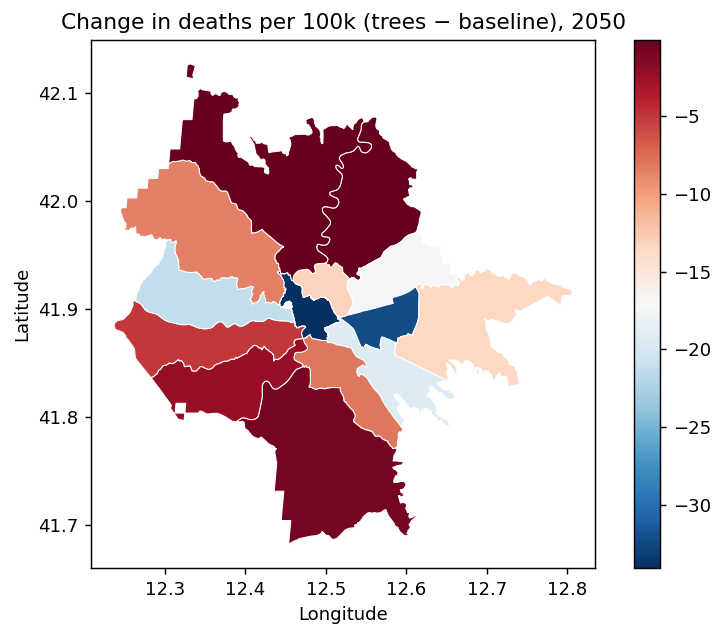

In [31]:
# map
muni_map = muni_ok.merge(tbl_muni[["muni_id","Δ per 100k"]], on="muni_id", how="left")
ax = muni_map.plot(column="Δ per 100k", cmap="RdBu_r", legend=True, 
                   edgecolor="white", linewidth=0.6, figsize=(6.5,5))
ax.set_title(f"Change in deaths per 100k (trees − baseline), {year_focus}")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.show()

In [32]:
years = [int(y) for y in H.event_id.tolist()]
i2050 = years.index(2050)

I_base = _row_to_grid(H.intensity, i2050, ref_data.shape)
I_tree = _row_to_grid(H_trees_dd.intensity, i2050, ref_data.shape)

avo_city_age = {}
per100k_age  = {}
for age_lbl, f in age_ifs.items():
    mdd_b = np.interp(I_base, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
    mdd_t = np.interp(I_tree, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
    pop = np.nan_to_num(age_on_ref[age_lbl], 0.0)
    d_b, d_t = float(np.nansum(pop * mdd_b)), float(np.nansum(pop * mdd_t))
    avo_city_age[age_lbl] = d_b - d_t
    per100k_age[age_lbl]  = (d_b - d_t) / float(pop.sum()) * 1e5

print("City avoided deaths in 2050 by age:", avo_city_age)
print("Avoided per 100k in 2050 by age:",   per100k_age)
print("Sum over ages:", sum(avo_city_age.values()))

City avoided deaths in 2050 by age: {'<15': 0.08733906709321426, '15-64': 17.769308259132146, '65+': 278.8532512627885}
Avoided per 100k in 2050 by age: {'<15': 0.03148616052136731, '15-64': 1.1234109436391584, '65+': 40.339339983586484}
Sum over ages: 296.70989858901385


**2 Maps: Original hazard vs hazard after policy**

In [33]:
year_focus = 2050
i_ev = list(H.event_id).index(year_focus)

I_base = _row_to_grid(H.intensity,         i_ev, ref_data.shape)
I_tree = _row_to_grid(H_trees_dd.intensity, i_ev, ref_data.shape)

# extent from ref_meta
T = ref_meta["transform"]; h, w = ref_meta["height"], ref_meta["width"]
xmin, ymax = T.c, T.f
xmax = xmin + T.a * w
ymin = ymax + T.e * h
extent = (xmin, xmax, ymin, ymax)

# already in ref CRS
fua_ref = fua.to_crs(ref_meta["crs"])

# common scale 
mask = CITY_MASK & np.isfinite(I_base) & np.isfinite(I_tree)
vals = np.concatenate([I_base[mask].ravel(), I_tree[mask].ravel()])
vmin = np.nanpercentile(vals, 1)
vmax = np.nanpercentile(vals, 99)

# Δ map (Trees − Baseline) 
D = (I_tree - I_base).astype(float)
dmask = CITY_MASK & np.isfinite(D)
dabs = np.abs(D[dmask])
dlim = np.nanpercentile(dabs, 99) if dabs.size else 1.0

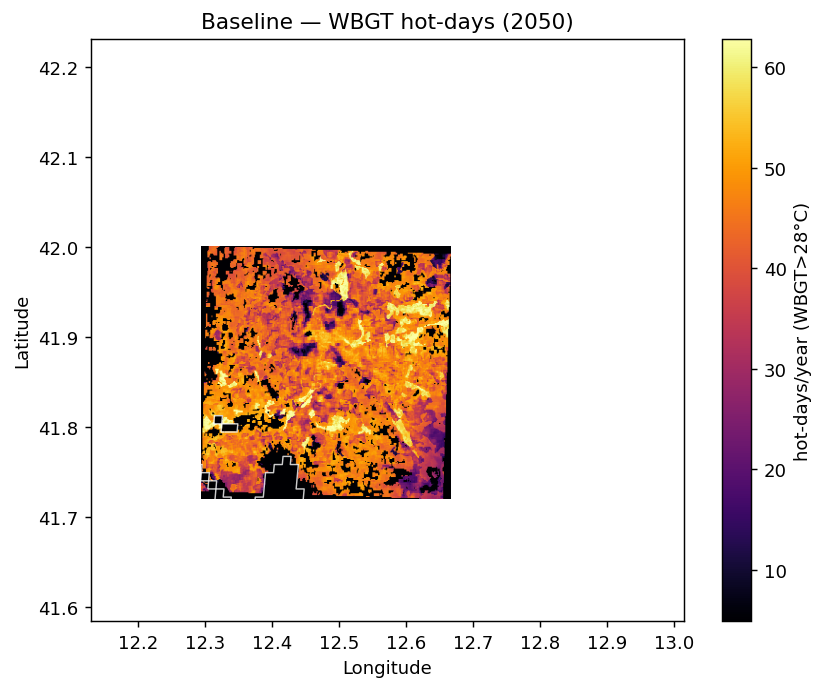

In [34]:
plt.figure(figsize=(6.8, 5.4))
im = plt.imshow(I_base, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
fua_ref.boundary.plot(ax=plt.gca(), color="white", linewidth=0.8, alpha=0.8)
plt.title(f"Baseline — WBGT hot-days ({year_focus})")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
cb = plt.colorbar(im); cb.set_label(getattr(H, "units", "hot-days / year"))
plt.tight_layout(); plt.show()

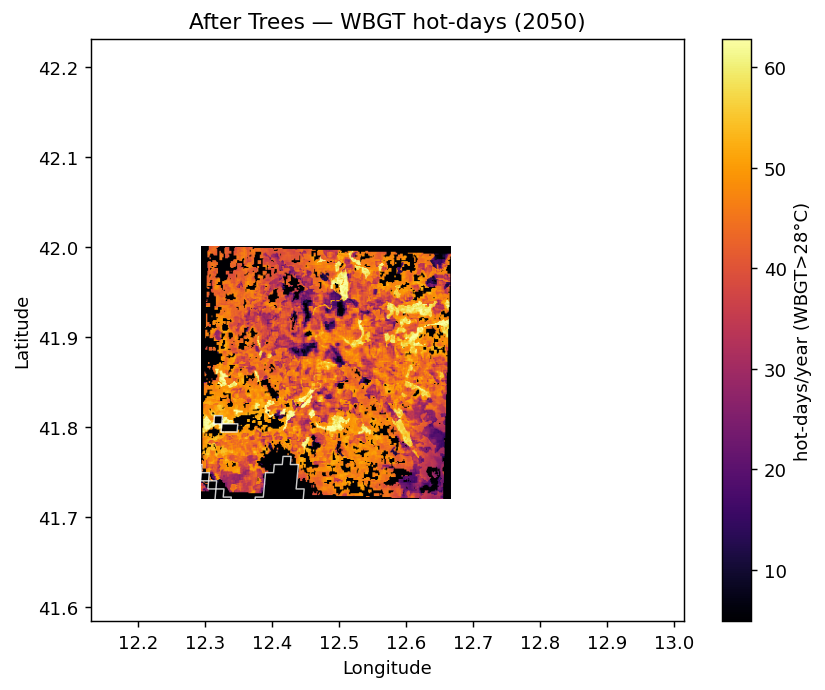

In [35]:
plt.figure(figsize=(6.8, 5.4))
im = plt.imshow(I_tree, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
fua_ref.boundary.plot(ax=plt.gca(), color="white", linewidth=0.8, alpha=0.8)
plt.title(f"After Trees — WBGT hot-days ({year_focus})")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
cb = plt.colorbar(im); cb.set_label(getattr(H, "units", "hot-days / year"))
plt.tight_layout(); plt.show()

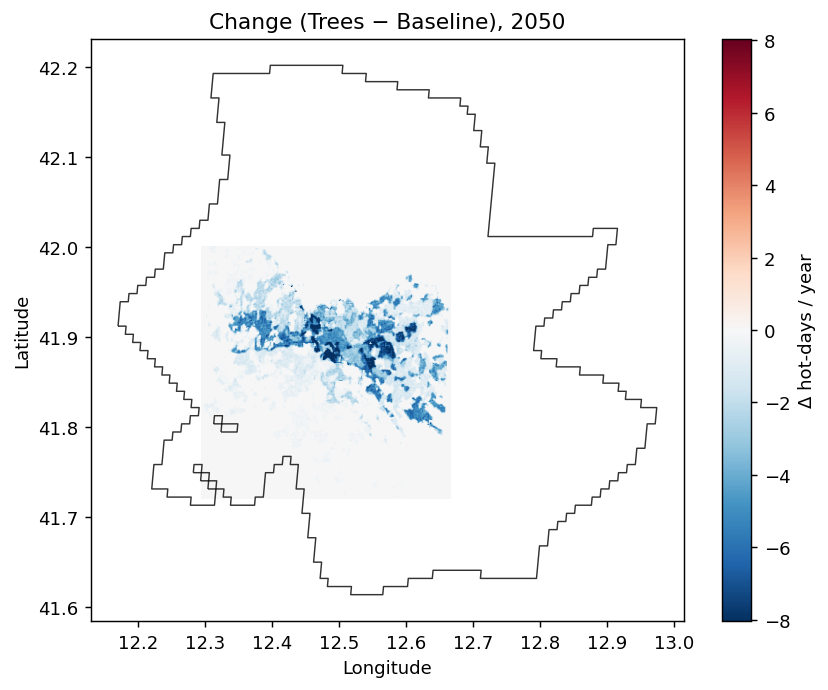

In [36]:
plt.figure(figsize=(6.8, 5.4))
im = plt.imshow(D, origin="upper", extent=extent, vmin=-dlim, vmax=dlim, cmap="RdBu_r")
fua_ref.boundary.plot(ax=plt.gca(), color="k", linewidth=0.8, alpha=0.8)
plt.title(f"Change (Trees − Baseline), {year_focus}")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
cb = plt.colorbar(im); cb.set_label("Δ hot-days / year")
plt.tight_layout(); plt.show()

In [37]:
# Validation (2050): pixel sums vs ImpactCalc; Municipio breakdown (incl. ID 0) 
import numpy as np
import pandas as pd
from climada.entity.impact_funcs import ImpactFuncSet
from climada.engine import ImpactCalc

# helpers
def _row_to_grid(mat, irow, shape):
    row = mat[irow, :]
    if hasattr(row, "toarray"):  
        row = row.toarray()
    return np.asarray(row).ravel().reshape(shape)

def mdd_lookup(I, f):
    return np.interp(I, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])

def _pop_sum_over_ages(mask):
    return sum(float(np.nansum(np.nan_to_num(age_on_ref[a], 0.0)[mask])) for a in age_ifs)

# Event : 2050
year = 2050
years = [int(y) for y in H.event_id.tolist()]
assert year in years, f"Year {year} not in hazard events: {years}"
i_ev = years.index(year)

# intensities on ref grid 
I_base = _row_to_grid(H.intensity,         i_ev, ref_data.shape)
I_tree = _row_to_grid(H_trees_dd.intensity, i_ev, ref_data.shape)

# masks 
OUT_PIX = CITY_MASK & (muni_on_ref == 0)

# deaths per pixel = sum_age(pop_age * mdd_age(I)) 
deaths_base = np.zeros_like(I_base, dtype=float)
deaths_tree = np.zeros_like(I_base, dtype=float)

for age_lbl, f in age_ifs.items():
    pop_age = np.nan_to_num(age_on_ref[age_lbl], nan=0.0)
    mdd_b = mdd_lookup(I_base, f)
    mdd_t = mdd_lookup(I_tree, f)
    deaths_base += np.where(CITY_MASK, pop_age * mdd_b, 0.0)
    deaths_tree += np.where(CITY_MASK, pop_age * mdd_t, 0.0)

deaths_avo = deaths_base - deaths_tree

# ImpactCalc totals using the same IF set 
impf_set_age = ImpactFuncSet(list(age_ifs.values())); impf_set_age.check()
impact_base  = ImpactCalc(exp, impf_set_age, H).impact()
impact_trees = ImpactCalc(exp, impf_set_age, H_trees_dd).impact()

tot_base_pix = float(np.nansum(deaths_base))
tot_tree_pix = float(np.nansum(deaths_tree))
tot_base_IC  = float(np.ravel(impact_base.at_event)[i_ev])
tot_tree_IC  = float(np.ravel(impact_trees.at_event)[i_ev])

# consistent per-100k denominator: sum of age rasters over CITY_MASK 
city_pop_age = _pop_sum_over_ages(CITY_MASK)
print(f"City pop (from ages) vs Exposure sum: {city_pop_age:.0f} vs {float(exp.gdf['value'].sum()):.0f}")

print(f"[{year}] pixel-sum vs ImpactCalc — base: {tot_base_pix:.2f} vs {tot_base_IC:.2f} "
      f"({tot_base_pix/city_pop_age*1e5:.1f} vs {tot_base_IC/city_pop_age*1e5:.1f} per 100k)")
print(f"[{year}] pixel-sum vs ImpactCalc — tree: {tot_tree_pix:.2f} vs {tot_tree_IC:.2f} "
      f"({tot_tree_pix/city_pop_age*1e5:.1f} vs {tot_tree_IC/city_pop_age*1e5:.1f} per 100k)")

# checks 
eps = 1e-6
assert abs(tot_base_pix - tot_base_IC)  < max(1e-3, eps*abs(tot_base_IC)  + 1.0), "Base totals mismatch"
assert abs(tot_tree_pix - tot_tree_IC)  < max(1e-3, eps*abs(tot_tree_IC)  + 1.0), "Trees totals mismatch"

# Municipio breakdown (using same age-sum population) 
M = muni_ok if 'muni_ok' in globals() else muni

rows = []
for mid, name in zip(M["muni_id"], M["muni_name"]):
    m = CITY_MASK & (muni_on_ref == int(mid))
    if not m.any():
        continue
    pop_m = _pop_sum_over_ages(m)
    d_b   = float(np.nansum(deaths_base[m]))
    d_t   = float(np.nansum(deaths_tree[m]))
    d_avo = d_b - d_t
    rows.append({
        "muni_id": int(mid), "muni_name": name,
        "deaths_base": d_b, "deaths_tree": d_t, "deaths_avo": d_avo,
        "pop_m": pop_m,
        "avo_per_100k": (d_avo / pop_m * 1e5) if pop_m > 0 else np.nan,
        "Δ per 100k":   ((d_t - d_b) / pop_m * 1e5) if pop_m > 0 else np.nan,
    })

# Outside Municipi (ID 0) to close mass balance 
if OUT_PIX.any():
    pop_0 = _pop_sum_over_ages(OUT_PIX)
    d_b0  = float(np.nansum(deaths_base[OUT_PIX]))
    d_t0  = float(np.nansum(deaths_tree[OUT_PIX]))
    d_a0  = d_b0 - d_t0
    rows.append({
        "muni_id": 0, "muni_name": "Fuori Municipi (FUA)",
        "deaths_base": d_b0, "deaths_tree": d_t0, "deaths_avo": d_a0,
        "pop_m": pop_0,
        "avo_per_100k": (d_a0 / pop_0 * 1e5) if pop_0 > 0 else np.nan,
        "Δ per 100k":   ((d_t0 - d_b0) / pop_0 * 1e5) if pop_0 > 0 else np.nan,
    })

benef_2050 = pd.DataFrame(rows).sort_values("deaths_avo", ascending=False).reset_index(drop=True)
display(benef_2050.head(10))

# check across raster vs table 
city_all = float(np.nansum(deaths_avo[CITY_MASK]))
sum_rows = float(benef_2050["deaths_avo"].sum())
print(f"City avoided deaths ({year}) — raster sum: {city_all:.3f}")
print(f"Sum of Municipio rows (incl. ID 0 if present): {sum_rows:.3f}")

City pop (from ages) vs Exposure sum: 2550386 vs 2550386
[2050] pixel-sum vs ImpactCalc — base: 2320.85 vs 2320.85 (91.0 vs 91.0 per 100k)
[2050] pixel-sum vs ImpactCalc — tree: 2024.14 vs 2024.14 (79.4 vs 79.4 per 100k)


,muni_id,muni_name,deaths_base,deaths_tree,deaths_avo,pop_m,avo_per_100k,Δ per 100k
0,1,Municipio Roma I,201.521966,140.404765,61.117201,179310.304688,34.084600,-34.084600
1,5,Municipio Roma V,219.234815,162.578938,56.655877,175631.617188,32.258359,-32.258359
2,7,Municipio Roma VII,247.382072,199.473491,47.908581,248257.707031,19.297923,-19.297923
3,4,Municipio Roma IV,180.792371,150.926266,29.866105,170982.498047,17.467346,-17.467346
4,13,Municipio Roma XIII,97.157596,69.294370,27.863226,131022.060547,21.266057,-21.266057
5,2,Municipio Roma II,141.078380,119.822634,21.255746,161208.326172,13.185266,-13.185266
6,6,Municipio Roma VI,141.090608,123.396363,17.694244,130848.190430,13.522727,-13.522727
7,14,Municipio Roma XIV,104.885609,91.397978,13.487631,158029.179688,8.534899,-8.534899
8,8,Municipio Roma VIII,110.571104,101.555209,9.015895,113726.645508,7.927689,-7.927689
9,12,Municipio Roma XII,112.258189,105.613947,6.644242,131970.550781,5.034640,-5.034640


City avoided deaths (2050) — raster sum: 296.710
Sum of Municipio rows (incl. ID 0 if present): 296.710


In [38]:
# Municipio population-weighted ΔWBGT summaries (July and Jun–Sep): ITT and ETT 
# ITT: Pop average effect, average cooling for residents 
# ETT: exclude 0: how much cooling where policy acted/on who policy acted
import numpy as np
import pandas as pd

def weighted_mean(values, weights):
    v = np.asarray(values, float).ravel()
    w = np.asarray(weights, float).ravel()
    m = np.isfinite(v) & np.isfinite(w) & (w > 0)
    return float(np.sum(v[m] * w[m]) / np.sum(w[m])) if m.any() else np.nan

# Masks
built_mask = (lcz_on_ref >= 1) & (lcz_on_ref <= 10) & HAZ_MASK
scope_mask = np.isfinite(dGVI_map_model) & CITY_MASK
M = muni_ok if 'muni_ok' in globals() else muni

def muni_popw_table(field_2d, title_col, muni_frame, include_zeros: bool):
    finite = np.isfinite(field_2d)
    if include_zeros:
        base_mask = built_mask & scope_mask & finite              # ITT: keep zeros
        tag = "ITT"
    else:
        base_mask = built_mask & scope_mask & finite & (field_2d != 0)  # ETT: exclude zeros
        tag = "ETT"

    rows = []
    for mid, name in zip(muni_frame["muni_id"], muni_frame["muni_name"]):
        m = (muni_on_ref == int(mid)) & base_mask
        if not np.any(m):
            continue
        vals = field_2d[m].astype(float)
        w    = pop_on_ref[m].astype(float)
        rows.append({
            "muni_id": int(mid),
            "muni_name": name,
            f"{title_col}_{tag}_popw_mean": weighted_mean(vals, w),
            f"{title_col}_{tag}_area_mean": float(np.nanmean(vals)),
            "pix": int(m.sum()),
            "pop_sum": float(np.nansum(w)),
            f"share_cooling_{tag}_popw": weighted_mean((vals < 0).astype(float), w),
        })

    out = pd.DataFrame(rows).sort_values(f"{title_col}_{tag}_popw_mean").reset_index(drop=True)

    # City line restricted to same scope + same Municipi set
    city_mask = np.isin(muni_on_ref, muni_frame["muni_id"].values) & base_mask
    if np.any(city_mask):
        vals_c = field_2d[city_mask].astype(float)
        w_c    = pop_on_ref[city_mask].astype(float)
        out = pd.concat([out, pd.DataFrame([{
            "muni_id": 999,
            "muni_name": f"Roma Capitale (built+policy, {tag})",
            f"{title_col}_{tag}_popw_mean": weighted_mean(vals_c, w_c),
            f"{title_col}_{tag}_area_mean": float(np.nanmean(vals_c)),
            "pix": int(city_mask.sum()),
            "pop_sum": float(np.nansum(w_c)),
            f"share_cooling_{tag}_popw": weighted_mean((vals_c < 0).astype(float), w_c),
        }])], ignore_index=True)

    return out

# July (m=7) 
m = 7
dWBGT_July = dWBGT_stack[m-1]  # (H, W)
df_jul_ITT = muni_popw_table(dWBGT_July, "ΔWBGT_Jul", M, include_zeros=True)
df_jul_ETT = muni_popw_table(dWBGT_July, "ΔWBGT_Jul", M, include_zeros=False)

display(df_jul_ITT)
display(df_jul_ETT)

# Jun–Sep seasonal mean (same as exceedance season) 
hot_months = [6, 7, 8, 9]
idx = [mm - 1 for mm in hot_months]
arr   = dWBGT_stack[idx, :, :].astype(float)   
count = np.sum(np.isfinite(arr), axis=0)
sum_  = np.nansum(arr, axis=0)
seasonal_mean = np.full_like(sum_, np.nan, dtype=float)
np.divide(sum_, count, out=seasonal_mean, where=(count > 0))

df_season_ITT = muni_popw_table(seasonal_mean, "ΔWBGT_Season", M, include_zeros=True)
df_season_ETT = muni_popw_table(seasonal_mean, "ΔWBGT_Season", M, include_zeros=False)

display(df_season_ITT)
display(df_season_ETT)

,muni_id,muni_name,ΔWBGT_Jul_ITT_popw_mean,ΔWBGT_Jul_ITT_area_mean,pix,pop_sum,share_cooling_ITT_popw
0,1,Municipio Roma I,-0.243444,-0.258388,1873,1.784637e+05,1.000000
1,5,Municipio Roma V,-0.208806,-0.181111,2369,1.731953e+05,1.000000
2,13,Municipio Roma XIII,-0.183127,-0.157672,2962,1.276024e+05,1.000000
3,7,Municipio Roma VII,-0.147730,-0.144454,3702,2.432035e+05,1.000000
4,4,Municipio Roma IV,-0.135270,-0.116953,3393,1.648577e+05,1.000000
5,2,Municipio Roma II,-0.100294,-0.105865,1754,1.599917e+05,1.000000
6,6,Municipio Roma VI,-0.099167,-0.087113,2305,1.255241e+05,1.000000
7,14,Municipio Roma XIV,-0.075604,-0.057142,4522,1.523454e+05,1.000000
8,8,Municipio Roma VIII,-0.060961,-0.057401,2071,1.069113e+05,1.000000
9,12,Municipio Roma XII,-0.039750,-0.035744,2961,1.284216e+05,1.000000


,muni_id,muni_name,ΔWBGT_Jul_ETT_popw_mean,ΔWBGT_Jul_ETT_area_mean,pix,pop_sum,share_cooling_ETT_popw
0,1,Municipio Roma I,-0.243444,-0.258388,1873,1.784637e+05,1.0
1,5,Municipio Roma V,-0.208806,-0.181111,2369,1.731953e+05,1.0
2,13,Municipio Roma XIII,-0.183127,-0.157672,2962,1.276024e+05,1.0
3,7,Municipio Roma VII,-0.147730,-0.144454,3702,2.432035e+05,1.0
4,4,Municipio Roma IV,-0.135270,-0.116953,3393,1.648577e+05,1.0
5,2,Municipio Roma II,-0.100294,-0.105865,1754,1.599917e+05,1.0
6,6,Municipio Roma VI,-0.099167,-0.087113,2305,1.255241e+05,1.0
7,14,Municipio Roma XIV,-0.075604,-0.057142,4522,1.523454e+05,1.0
8,8,Municipio Roma VIII,-0.060961,-0.057401,2071,1.069113e+05,1.0
9,12,Municipio Roma XII,-0.039750,-0.035744,2961,1.284216e+05,1.0


,muni_id,muni_name,ΔWBGT_Season_ITT_popw_mean,ΔWBGT_Season_ITT_area_mean,pix,pop_sum,share_cooling_ITT_popw
0,1,Municipio Roma I,-0.257328,-0.273142,1873,1.784637e+05,1.000000
1,5,Municipio Roma V,-0.220726,-0.191455,2369,1.731953e+05,1.000000
2,13,Municipio Roma XIII,-0.193603,-0.166691,2962,1.276024e+05,1.000000
3,7,Municipio Roma VII,-0.156176,-0.152718,3702,2.432035e+05,1.000000
4,4,Municipio Roma IV,-0.143014,-0.123648,3393,1.648577e+05,1.000000
5,2,Municipio Roma II,-0.106020,-0.111915,1754,1.599917e+05,1.000000
6,6,Municipio Roma VI,-0.104829,-0.092089,2305,1.255241e+05,1.000000
7,14,Municipio Roma XIV,-0.079931,-0.060410,4522,1.523454e+05,1.000000
8,8,Municipio Roma VIII,-0.064449,-0.060685,2071,1.069113e+05,1.000000
9,12,Municipio Roma XII,-0.042024,-0.037790,2961,1.284216e+05,1.000000


,muni_id,muni_name,ΔWBGT_Season_ETT_popw_mean,ΔWBGT_Season_ETT_area_mean,pix,pop_sum,share_cooling_ETT_popw
0,1,Municipio Roma I,-0.257328,-0.273142,1873,1.784637e+05,1.0
1,5,Municipio Roma V,-0.220726,-0.191455,2369,1.731953e+05,1.0
2,13,Municipio Roma XIII,-0.193603,-0.166691,2962,1.276024e+05,1.0
3,7,Municipio Roma VII,-0.156176,-0.152718,3702,2.432035e+05,1.0
4,4,Municipio Roma IV,-0.143014,-0.123648,3393,1.648577e+05,1.0
5,2,Municipio Roma II,-0.106020,-0.111915,1754,1.599917e+05,1.0
6,6,Municipio Roma VI,-0.104829,-0.092089,2305,1.255241e+05,1.0
7,14,Municipio Roma XIV,-0.079931,-0.060410,4522,1.523454e+05,1.0
8,8,Municipio Roma VIII,-0.064449,-0.060685,2071,1.069113e+05,1.0
9,12,Municipio Roma XII,-0.042024,-0.037790,2961,1.284216e+05,1.0


> **Interpretation:**
> - Exclude zeros (no Δ=0): “How much cooling did the policy produce where it acted?”. Kind of Effect on treated.
> - Include zeros: “What’s the average cooling for residents of the policy area overall?”. Kind of Intent-to-treat (include zeros) => show the population-average effect.

**Saving for later**

In [39]:
# regions + muni (vector) 
gpkg_path = OUT / "rome_regions.gpkg"
regions.to_file(gpkg_path, layer="regions", driver="GPKG")
muni.to_file(gpkg_path,    layer="muni",    driver="GPKG")

# look up table 
lut = regions[["muni_id","muni_name"]].drop_duplicates().sort_values("muni_id")
lut.to_csv(OUT / "muni_lut.csv", index=False)

# rasterized label grid on WBGT ref grid 
import rasterio as rio
from rasterio.features import rasterize

regions_ref = regions.to_crs(ref_meta["crs"])
shapes = [(g, int(i)) for g, i in zip(regions_ref.geometry, regions_ref["muni_id"])]
muni_on_ref = rasterize(
    shapes=shapes,
    out_shape=(ref_meta["height"], ref_meta["width"]),
    transform=ref_meta["transform"],
    fill=-1, dtype="int32", all_touched=False
)

tif_path = OUT / "muni_on_ref.tif"
meta = ref_meta.copy()
meta.update(dtype="int32", nodata=-1, compress="LZW")
with rio.open(tif_path, "w", **meta) as dst:
    dst.write(muni_on_ref.astype("int32"), 1)

print("Wrote:", gpkg_path, "and", tif_path)

Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/rome_regions.gpkg and /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/muni_on_ref.tif


In [40]:
# After-trees hazard
# ensuring metadata is complete so no pb with ImpactCalc 
n_ev = len(H.event_id)
if not getattr(H_trees_dd, "haz_type", None):
    H_trees_dd.haz_type = "HEAT"
if not hasattr(H_trees_dd, "event_name") or len(getattr(H_trees_dd, "event_name", [])) != n_ev:
    H_trees_dd.event_name = np.array([f"HEAT_{int(y)}" for y in H.event_id], dtype=object)
if not hasattr(H_trees_dd, "date") or len(getattr(H_trees_dd, "date", [])) != n_ev:
    H_trees_dd.date = np.array([np.datetime64(f"{int(y)}-07-01")] * n_ev)
if not getattr(H_trees_dd, "frequency_unit", None):
    H_trees_dd.frequency_unit = "1/year"
if not hasattr(H_trees_dd, "frequency") or len(getattr(H_trees_dd, "frequency", [])) != n_ev:
    H_trees_dd.frequency = np.ones(n_ev, dtype=float)

# Hazard
H_TREES_PATH = INT / "hazard_HEAT_trees_dd.h5"
H_trees_dd.write_hdf5(H_TREES_PATH)

AUX_PATH = INT / "trees_policy_artifacts.npz"
np.savez_compressed(
    AUX_PATH,
    f_ref=f_ref.astype("float32"),
    dWBGT_stack=dWBGT_stack.astype("float32"),   # (12, H, W)
    dGVI_points=dGVI_points.astype("float32")    # (H, W), points on 0–100 scale
)

print("Wrote:",
      "\n -", H_TREES_PATH,
      "\n -", AUX_PATH)

2025-11-07 12:17:06,949 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
Wrote: 
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/interim/hazard_HEAT_trees_dd.h5 
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/interim/trees_policy_artifacts.npz


In [41]:
# vegetation outputs 
from pathlib import Path
import pandas as pd
import numpy as np

OUT = Path(OUT)  
OUT.mkdir(parents=True, exist_ok=True)

assert 'trees_tbl' in globals(), "NB5: define `trees_tbl` (per-Municipio ΔGVI on 0–1 scale)."
need = {'muni_id','dGVI'}
assert need.issubset(trees_tbl.columns), f"NB5: trees_tbl must have columns {need}."

trees_tbl_out = (trees_tbl[['muni_id','dGVI']]
                 .assign(muni_id=lambda d: d['muni_id'].astype(int),
                         dGVI=lambda d: d['dGVI'].astype(float)))
trees_tbl_out.to_csv(OUT / "trees_tbl.csv", index=False)
print("✓ Wrote", OUT / "trees_tbl.csv",
      "| ΣΔGVI (0–1) =", float(np.clip(trees_tbl_out['dGVI'], 0, None).sum()))

✓ Wrote /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/trees_tbl.csv | ΣΔGVI (0–1) = 0.29893230610533894
